Notebook structure 

Project Overview 

Problem Statement

Importing Libraries

Data Loading

Exploratory Data Analysis (EDA)

Data Cleaning & Preprocessing

Feature Engineering

Model Building

Model Evaluation

Results & Insights

Conclusion

# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings("ignore")
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Data Loading

In [3]:
data = pd.read_csv("AIML Dataset.csv")
data

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


# Exploratory Data Analysis (EDA)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
data.shape

(6362620, 11)

In [6]:
data.dtypes.value_counts()

float64    5
int64      3
object     3
Name: count, dtype: int64

In [7]:
data.isna().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [8]:
data.duplicated().sum()

0

In [9]:
data.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

## Column Renaming for Better Readability


To improve clarity and make the dataset easier to interpret, the columns are renamed using descriptive and self-explanatory labels.  
This helps avoid ambiguity during analysis and model development.


In [10]:
# Rename columns to more descriptive names for better interpretability
data.rename(columns={
    'step': 'transaction_hour',
    'type': 'transaction_type',
    'amount': 'transaction_amount',
    'nameOrig': 'origin_account',
    'oldbalanceOrg': 'origin_balance_before',
    'newbalanceOrig': 'origin_balance_after',
    'nameDest': 'destination_account',
    'oldbalanceDest': 'destination_balance_before',
    'newbalanceDest': 'destination_balance_after',
    'isFraud': 'fraud',
    'isFlaggedFraud': 'flagged_as_fraud'
}, inplace=True)



The features are grouped into numerical and categorical variables.  
This separation is important for preprocessing steps such as scaling, encoding, and feature selection.


In [11]:
numerical_columns = ['transaction_hour', 'transaction_amount','origin_balance_before', 'origin_balance_after','destination_balance_before','destination_balance_after']
categorical_column = [c for c in data.columns if c not in numerical_columns]

## Descriptive Statistics of Numerical Features


Summary statistics are computed to understand the distribution, scale, and variability of the numerical features.  
This helps identify potential outliers, skewness, and data quality issues before modeling.


In [12]:
data[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_hour,6362620.00,243.40,142.33,1.00,156.00,239.00,335.00,743.00
transaction_amount,6362620.00,179861.90,603858.23,0.00,13389.57,74871.94,208721.48,92445516.64
origin_balance_before,6362620.00,833883.10,2888242.67,0.00,0.00,14208.00,107315.18,59585040.37
origin_balance_after,6362620.00,855113.67,2924048.50,0.00,0.00,0.00,144258.41,49585040.37
destination_balance_before,6362620.00,1100701.67,3399180.11,0.00,0.00,132705.66,943036.71,356015889.35
destination_balance_after,6362620.00,1224996.40,3674128.94,0.00,0.00,214661.44,1111909.25,356179278.92


In [13]:
categorical_column

['transaction_type',
 'origin_account',
 'destination_account',
 'fraud',
 'flagged_as_fraud']

In [14]:
data['origin_account'].value_counts()

origin_account
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
              ..
C98968405      1
C720209255     1
C1567523029    1
C644777639     1
C1280323807    1
Name: count, Length: 6353307, dtype: int64

In [15]:
data['destination_account'].value_counts()

destination_account
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
              ... 
M1470027725      1
M1330329251      1
M1784358659      1
M2081431099      1
C2080388513      1
Name: count, Length: 2722362, dtype: int64

## Distribution of Transaction Types


This visualization shows the frequency of each transaction type in the dataset.  
Understanding transaction distribution helps identify dominant transaction patterns and potential imbalance across transaction categories.


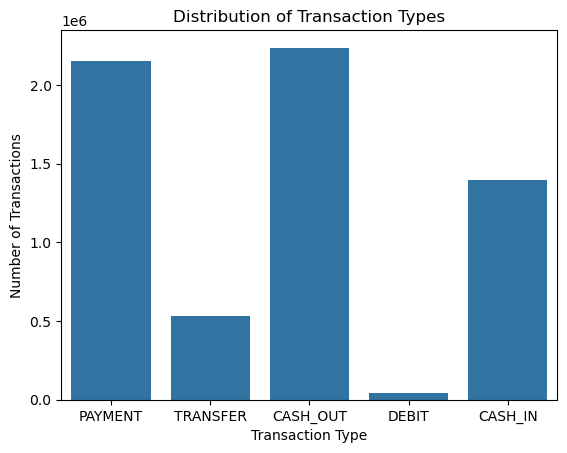

In [16]:
# Visualize the frequency of different transaction types
sns.countplot(x=data['transaction_type'])
plt.title("Distribution of Transaction Types")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.show()


## Distribution of Fraudulent vs Non-Fraudulent Transactions


This plot shows the class distribution of the target variable.  
Understanding the balance between fraudulent and non-fraudulent transactions is crucial, as fraud datasets are typically highly imbalanced.


In [17]:
data['fraud'].value_counts()

fraud
0    6354407
1       8213
Name: count, dtype: int64

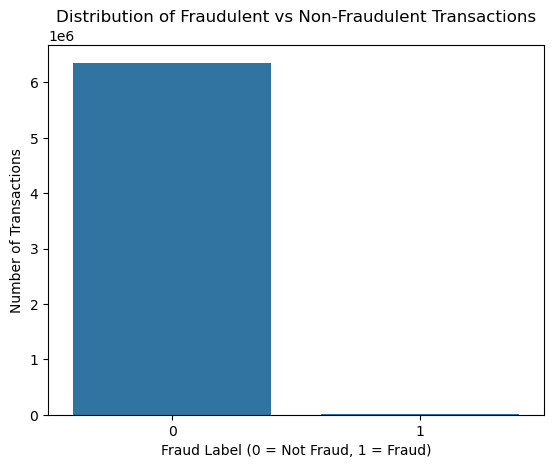

In [18]:
sns.countplot(x=data['fraud'])
plt.title("Distribution of Fraudulent vs Non-Fraudulent Transactions")
plt.xlabel("Fraud Label (0 = Not Fraud, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()


The above plot reveals a strong class imbalance, with fraudulent transactions representing a very small fraction of the data.  
This imbalance must be addressed during model training and evaluation to avoid biased predictions.


## Distribution of System-Flagged Fraud Transactions


This visualization shows how often transactions are flagged as fraudulent by the existing system.  
It helps assess how conservative or aggressive the rule-based fraud flagging mechanism is.


In [19]:
data['flagged_as_fraud'].value_counts()

flagged_as_fraud
0    6362604
1         16
Name: count, dtype: int64

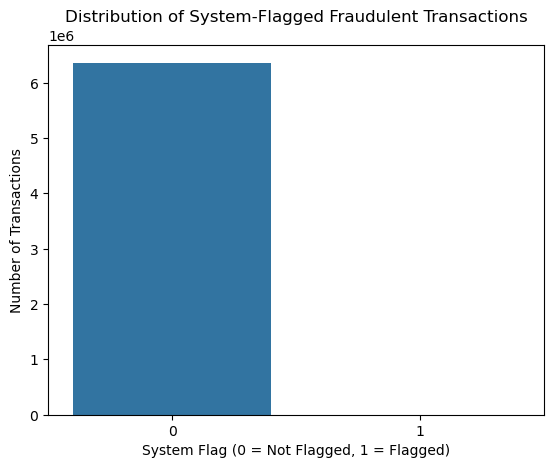

In [20]:
sns.countplot(x=data['flagged_as_fraud'])
plt.title("Distribution of System-Flagged Fraudulent Transactions")
plt.xlabel("System Flag (0 = Not Flagged, 1 = Flagged)")
plt.ylabel("Number of Transactions")
plt.show()


The above distribution indicates that only a very small number of transactions are flagged by the system.  
Comparing this with the actual fraud distribution can highlight gaps where fraudulent transactions may go undetected.


### Why Machine Learning Is Needed for Fraud Detection

A comparison between actual fraudulent transactions and system-flagged fraud highlights a significant gap.  
Although fraud cases exist in the dataset, only a very small proportion are identified by the existing rule-based system.

This indicates that traditional fraud detection methods are limited and unable to capture the complex and evolving nature of fraudulent behavior.  
Fraud often depends on subtle patterns across multiple features such as transaction amount, account balances, timing, and transaction type — patterns that fixed rules cannot effectively model.

Machine learning addresses this limitation by learning from historical transaction data, identifying hidden relationships, and adapting to new fraud strategies.  
This makes machine learning a more effective and scalable solution for improving fraud detection accuracy and strengthening financial security.


In [20]:
Comparing the distributions of actual fraud and system-flagged fraud reveals a clear gap.  
While fraudulent transactions exist in the dataset, only a very small fraction of them are flagged by the existing system.

This suggests that the current rule-based approach is highly limited and likely misses many fraudulent activities.  
Fraud patterns are often complex, evolving, and influenced by multiple features such as transaction amount, timing, and account behavior — relationships that fixed rules struggle to capture.

Machine learning models can learn these hidden patterns from historical data, adapt to new fraud strategies, and detect suspicious behavior beyond simple thresholds.  
As a result, machine learning provides a more robust and scalable approach to improving fraud detection and enhancing transaction security.


SyntaxError: invalid character '—' (U+2014) (3457236865.py, line 5)

## Analyzing System-Flagged Fraudulent Transactions

To understand how the current system identifies suspicious transactions, we filter the dataset to include only those transactions flagged as fraudulent.  
This allows a focused analysis of system-flagged transactions and comparison with actual fraud cases.



In [25]:
# Filter transactions that the system has flagged as potentially fraudulent
system_detection = data[data['flagged_as_fraud'] == 1].reset_index(drop=True)

# Display the filtered dataset
system_detection


,transaction_hour,transaction_type,transaction_amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud,flagged_as_fraud
0,212,TRANSFER,4953893.08,C728984460,4953893.08,4953893.08,C639921569,0.00,0.00,1,1
1,250,TRANSFER,1343002.08,C1100582606,1343002.08,1343002.08,C1147517658,0.00,0.00,1,1
2,279,TRANSFER,536624.41,C1035541766,536624.41,536624.41,C1100697970,0.00,0.00,1,1
3,387,TRANSFER,4892193.09,C908544136,4892193.09,4892193.09,C891140444,0.00,0.00,1,1
4,425,TRANSFER,10000000.00,C689608084,19585040.37,19585040.37,C1392803603,0.00,0.00,1,1
5,425,TRANSFER,9585040.37,C452586515,19585040.37,19585040.37,C1109166882,0.00,0.00,1,1
6,554,TRANSFER,3576297.10,C193696150,3576297.10,3576297.10,C484597480,0.00,0.00,1,1
7,586,TRANSFER,353874.22,C1684585475,353874.22,353874.22,C1770418982,0.00,0.00,1,1
8,617,TRANSFER,2542664.27,C786455622,2542664.27,2542664.27,C661958277,0.00,0.00,1,1
9,646,TRANSFER,10000000.00,C19004745,10399045.08,10399045.08,C1806199534,0.00,0.00,1,1


In [26]:
system_detection.describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_hour,16.00,537.56,181.90,212.00,415.50,601.50,678.75,741.00
transaction_amount,16.00,4861597.73,3572499.10,353874.22,2242748.72,4234245.09,7883451.38,10000000.00
origin_balance_before,16.00,7817869.01,6972668.53,353874.22,3013980.26,4923043.08,12128347.57,19585040.37
origin_balance_after,16.00,7817869.01,6972668.53,353874.22,3013980.26,4923043.08,12128347.57,19585040.37
destination_balance_before,16.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
destination_balance_after,16.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
fraud,16.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00
flagged_as_fraud,16.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00


## Summary of System-Flagged Fraud Transactions


The subset of transactions flagged by the system contains 16 transactions, all of which are actual fraud cases (`fraud = 1`). 
All flagged transactions are of the **TRANSFER** type, indicating that the system primarily targets high-value transfers rather than other transaction types.  
Key observations from the descriptive statistics:

- **Transaction Hour:** Fraudulent transactions occur throughout the day (range: 212 to 741), with a mean around 538, suggesting fraud is not limited to specific hours.  
- **Transaction Amounts:** Transactions flagged by the system are high-value transfers, with amounts ranging from ~354k to 10 million and an average around 4.86 million.  
- **Origin Account Balances:** The sending accounts often have large balances, ranging from ~354k to ~19.6 million, which allows for these high-value transfers.  
- **Destination Account Balances:** All destination accounts show a zero balance both before and after, indicating that the system flags transfers to empty or suspicious accounts.  
- **Fraud Detection:** All transactions flagged are true frauds (`fraud = 1`), meaning the system is precise for the cases it flags, but only a small subset of total fraud is captured.

**Key Takeaway:**  
The system appears highly conservative, flagging only transactions with extreme values or certain account patterns. While precision is high for flagged cases, many fraudulent transactions in other ranges or patterns may go undetected.  

**Implication for Machine Learning:**  
Machine learning can analyze the full dataset, learn subtle patterns across multiple features, and identify fraud cases that the current system misses.  
This approach could increase recall while maintaining precision, improving overall security and detection coverage.


In [27]:
def numerical_plot (data):
    for col in numerical_columns:
        plt.figure(figsize=(20 ,8))
        plt.subplot(121)
        sns.boxplot(x = data[col])
        plt.title(f"Box Plot of {col.capitalize()}")

        plt.subplot(122)
        sns.histplot(x = data[col])
        plt.title(f"Distribution of {col.capitalize()}")

        plt.tight_layout()
        plt.show()

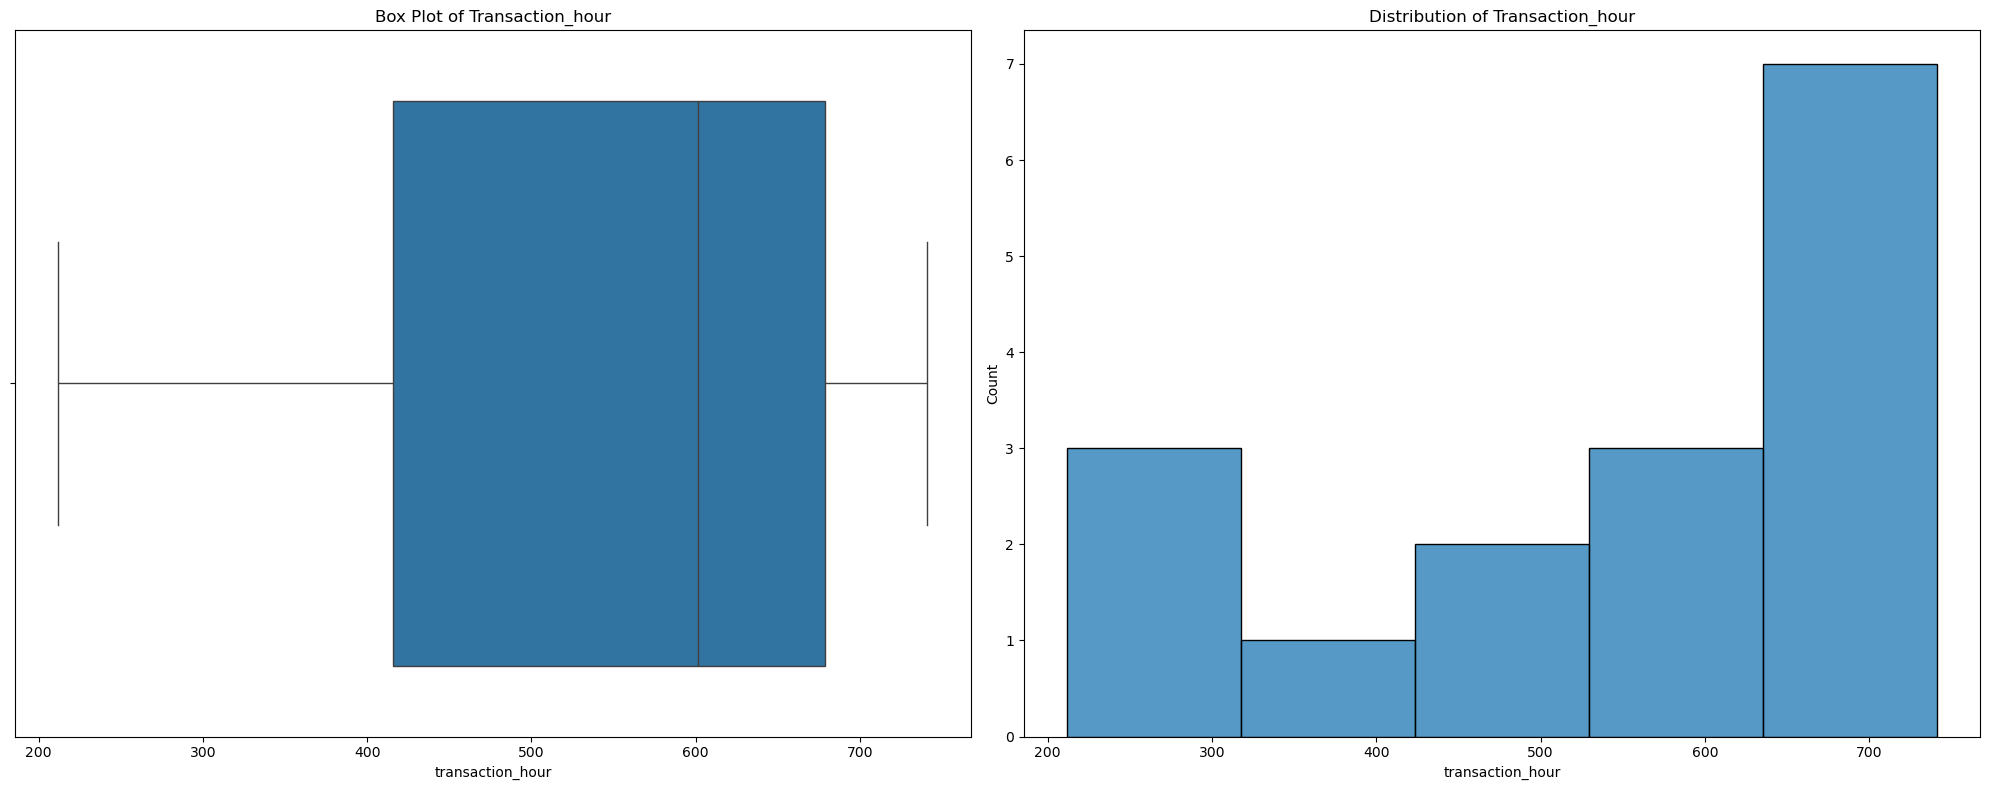

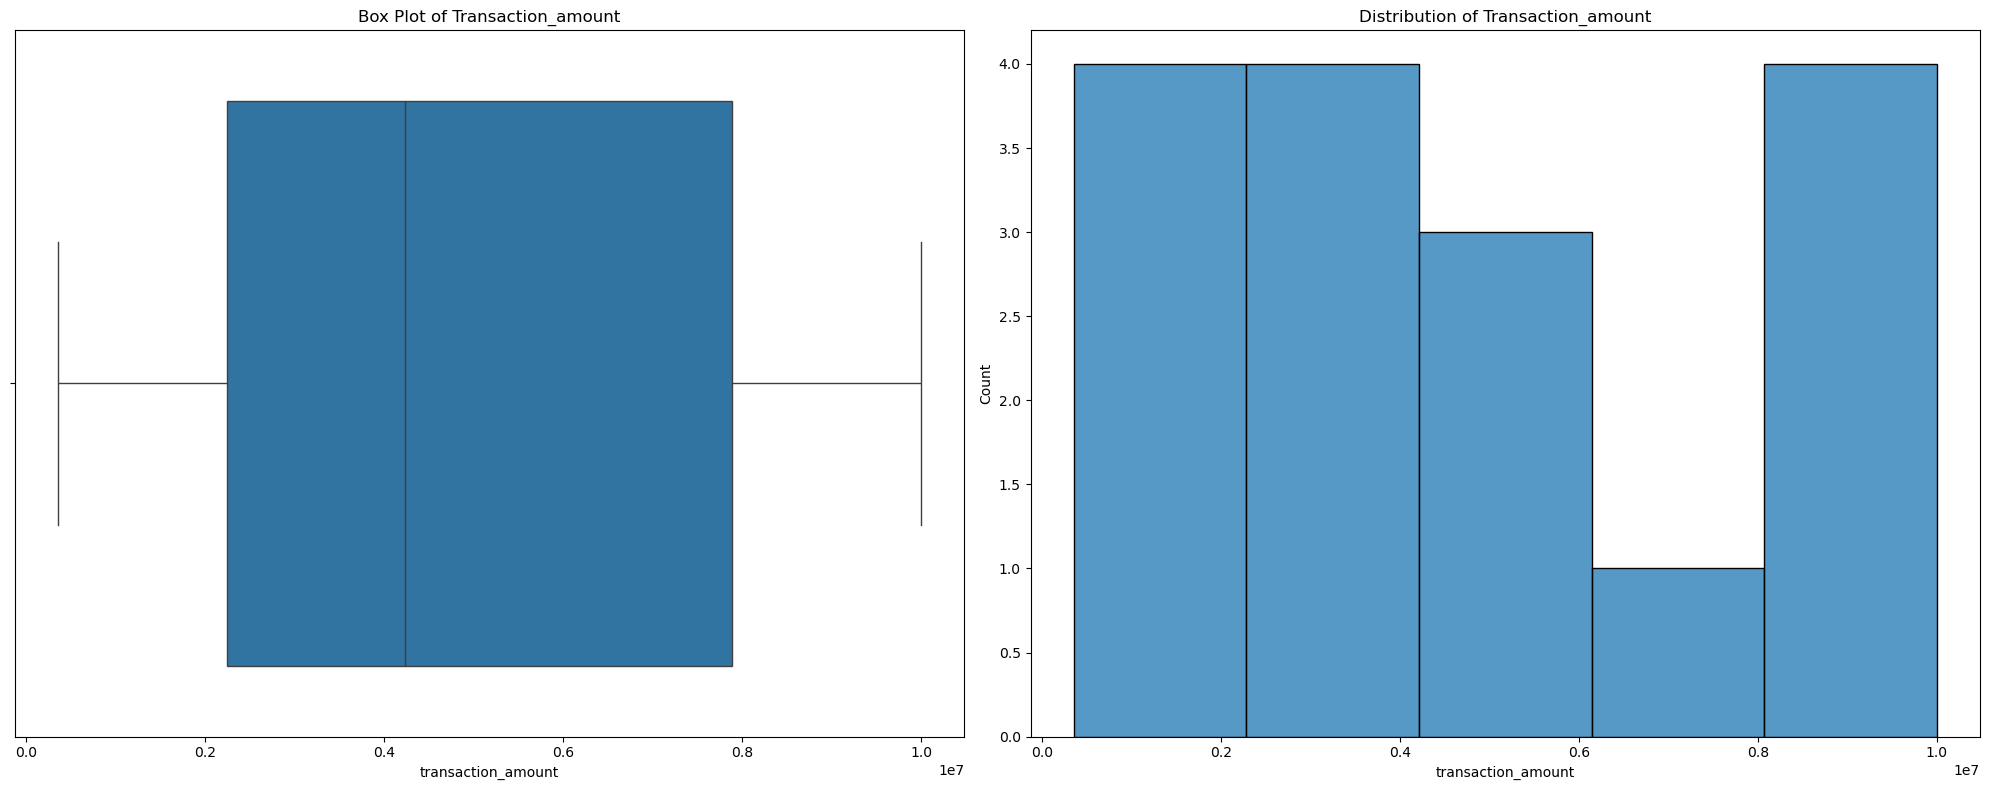

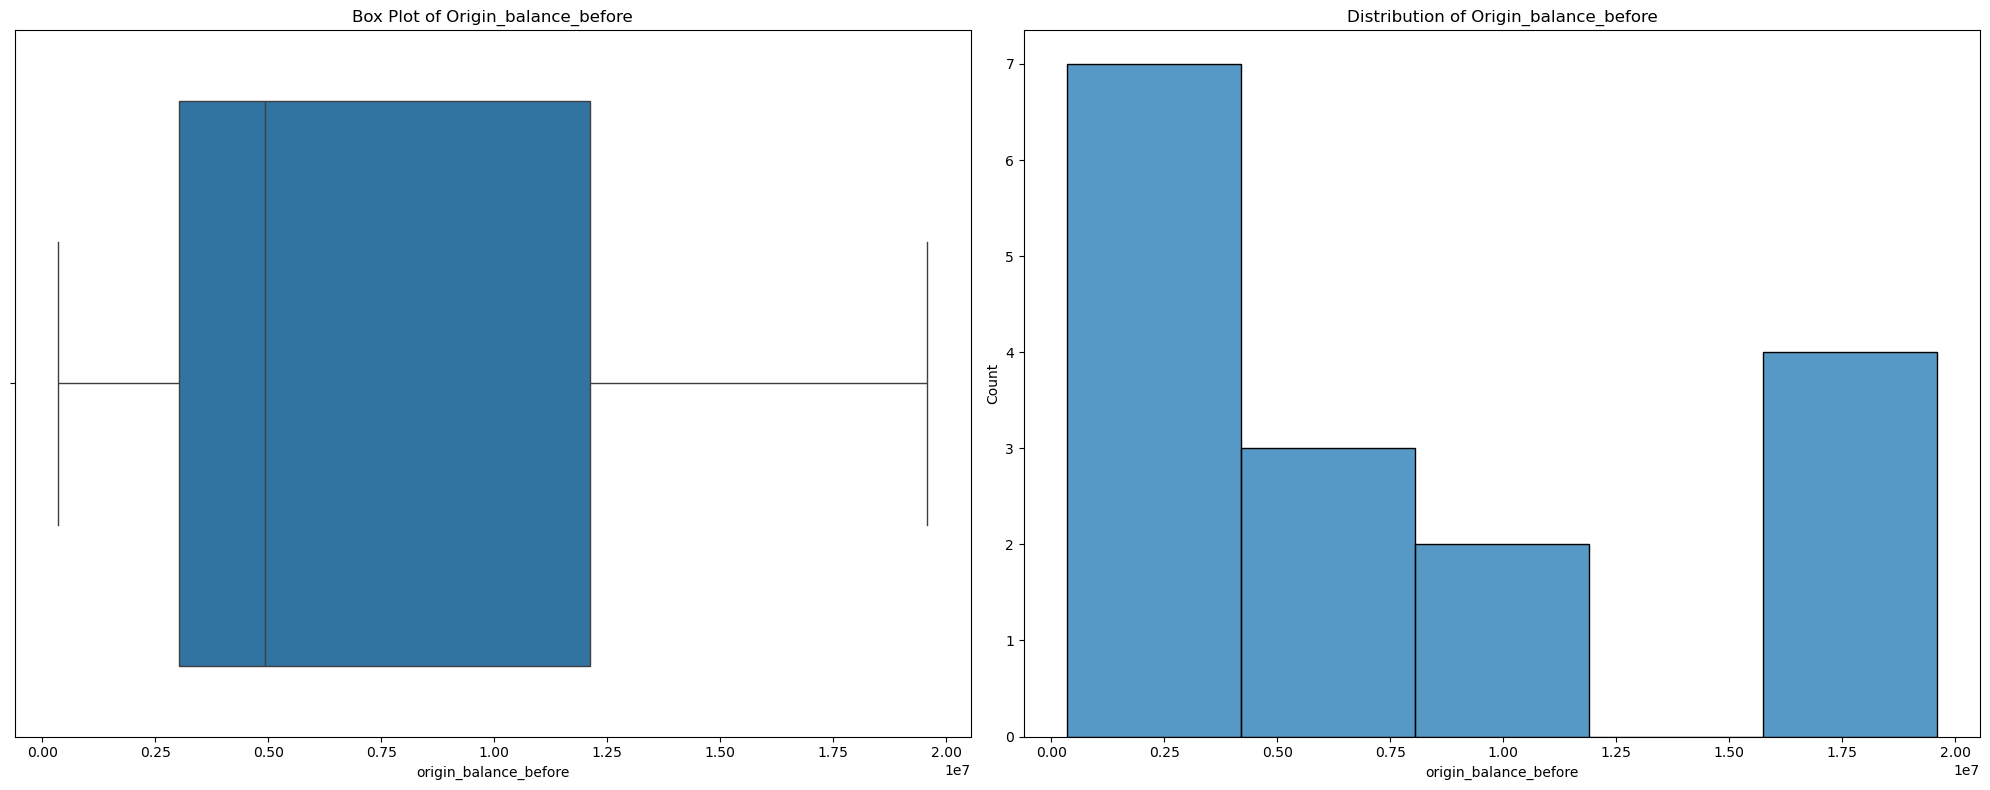

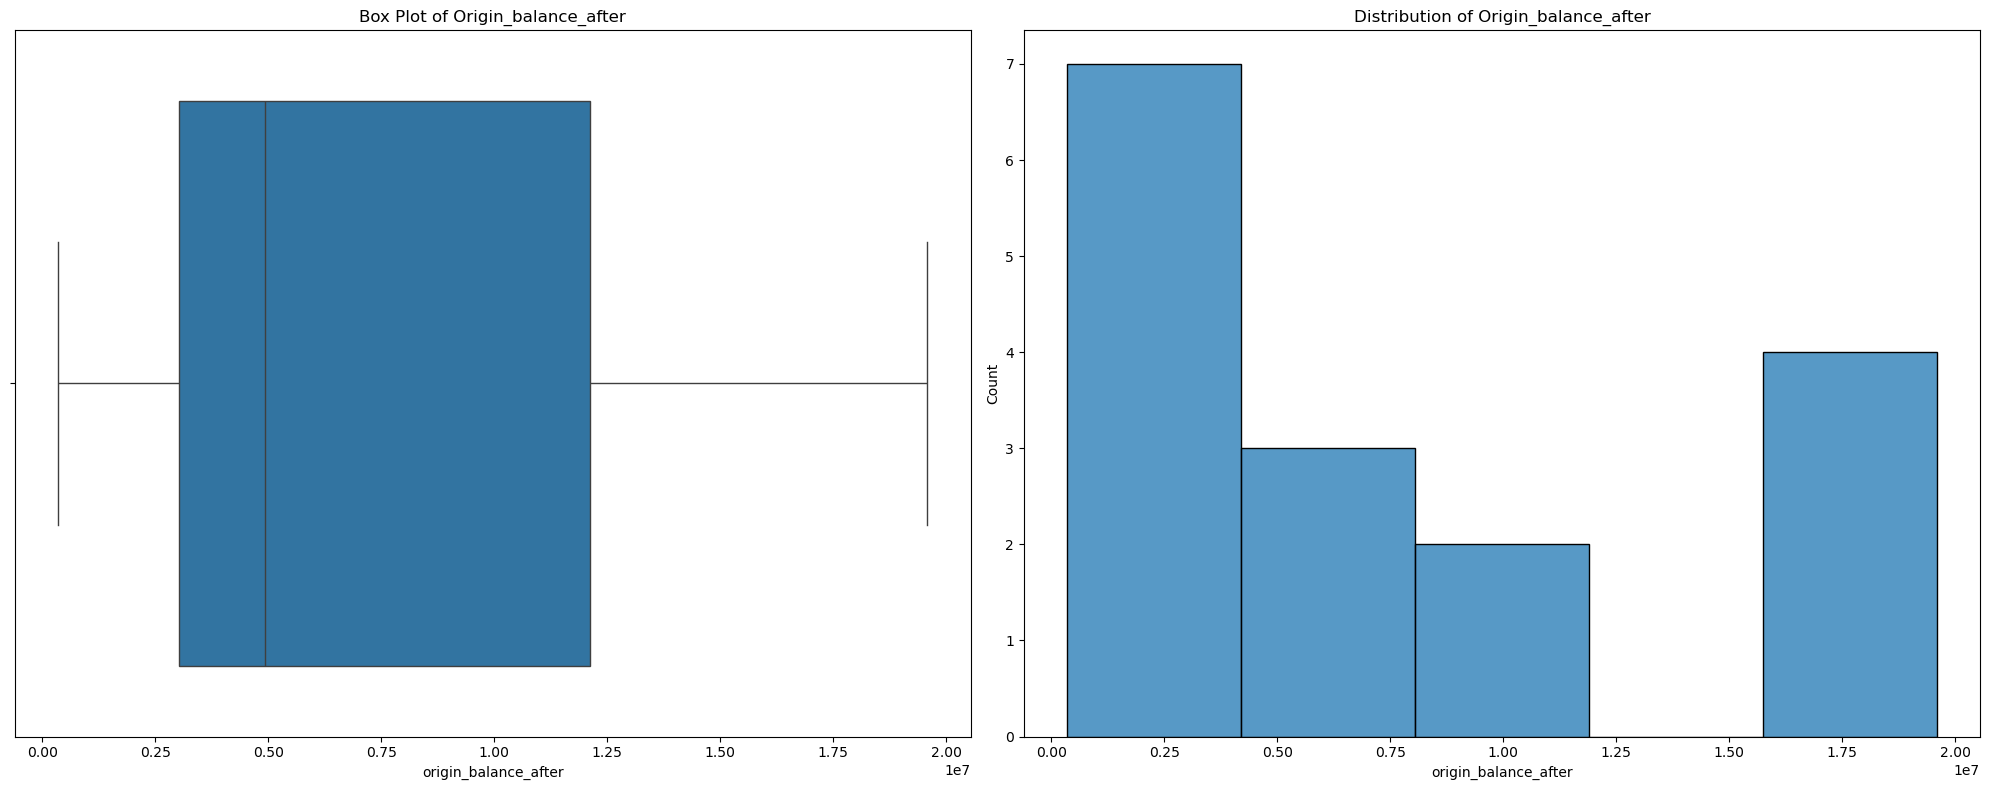

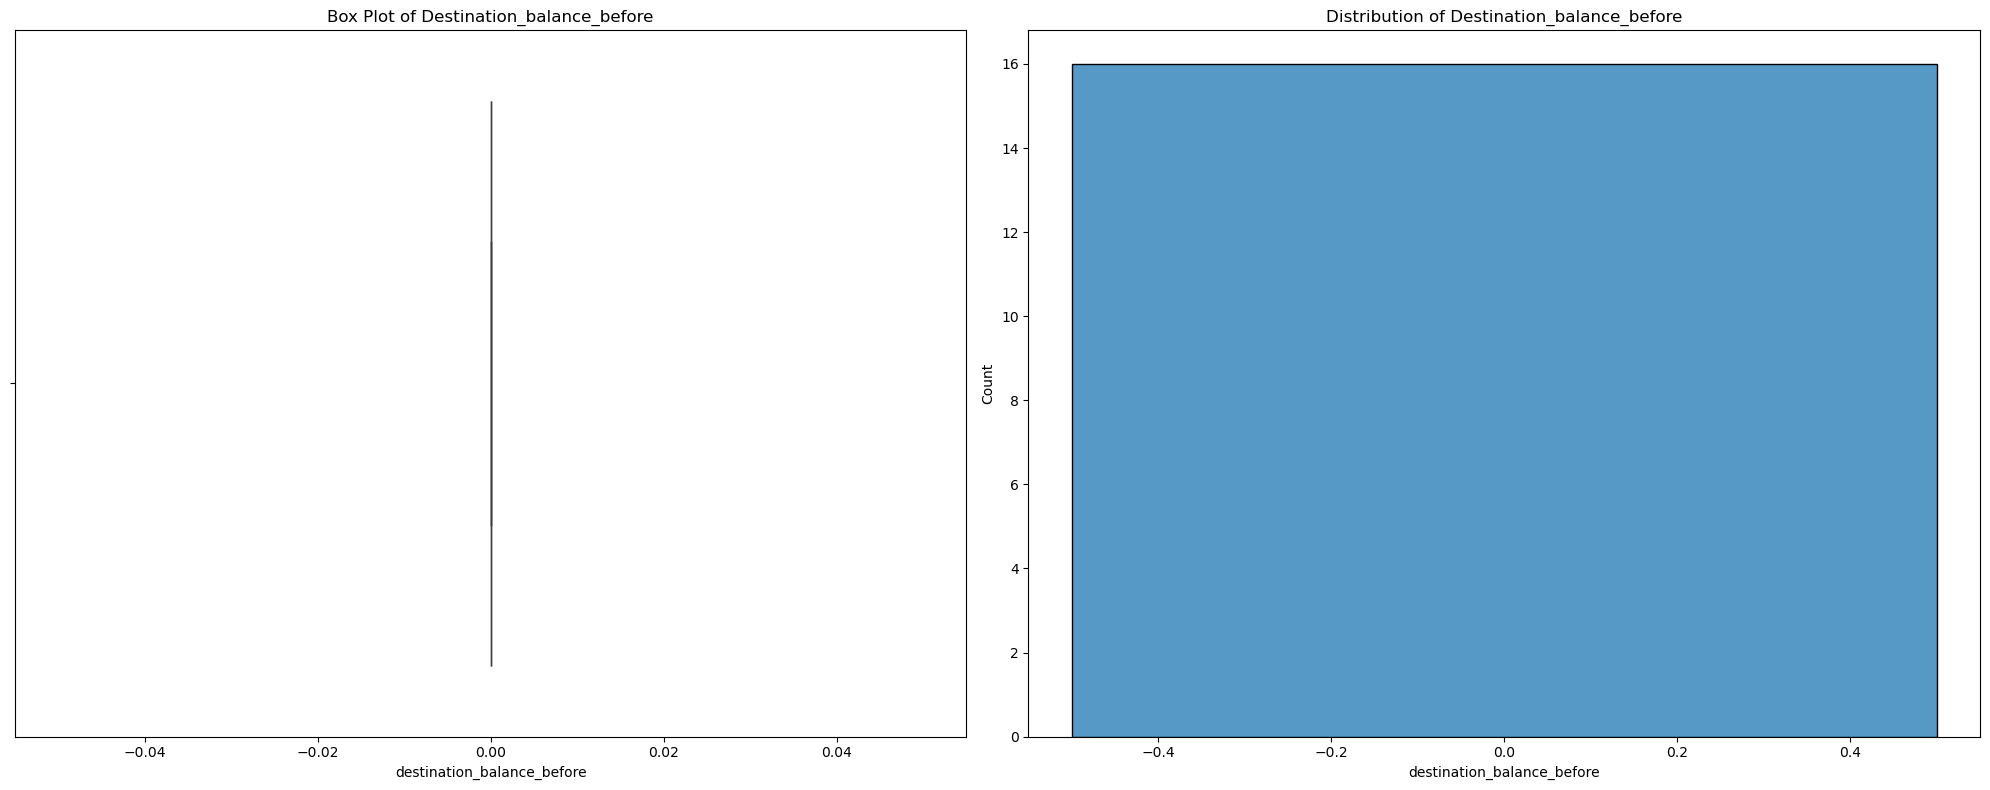

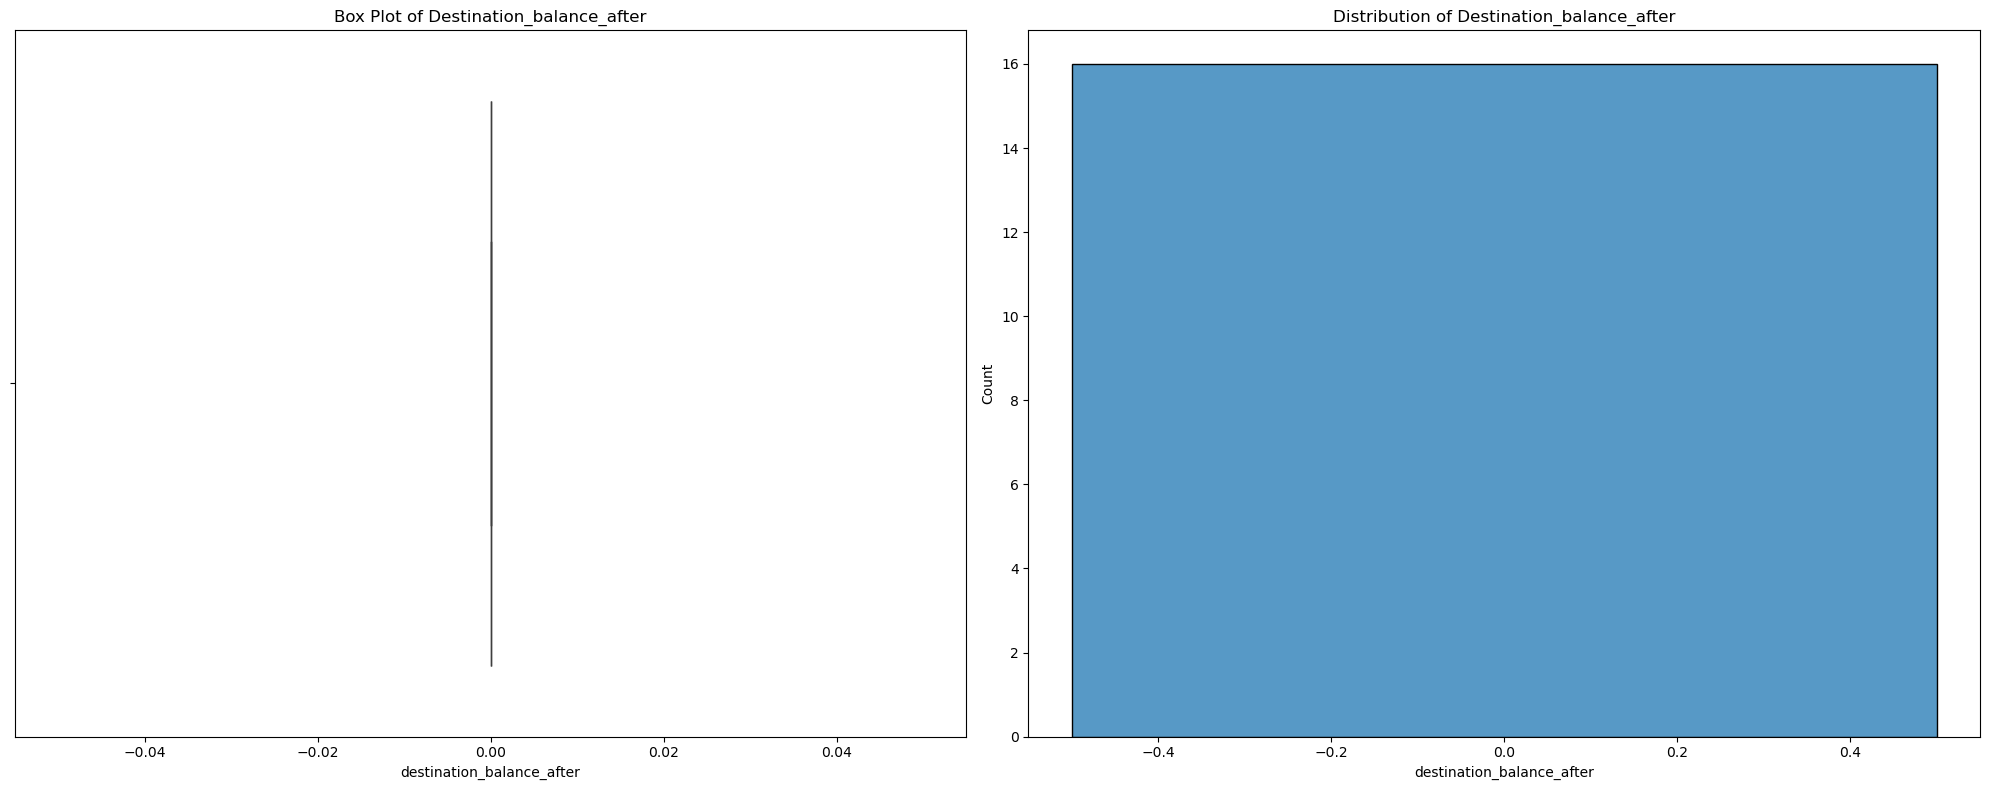

In [29]:
numerical_plot(system_detection)

## Correlation Analysis of Numerical Features

A correlation heatmap helps identify relationships between numerical features.  
Strong correlations may indicate redundant features or highlight patterns that can be leveraged by machine learning models to detect fraud.


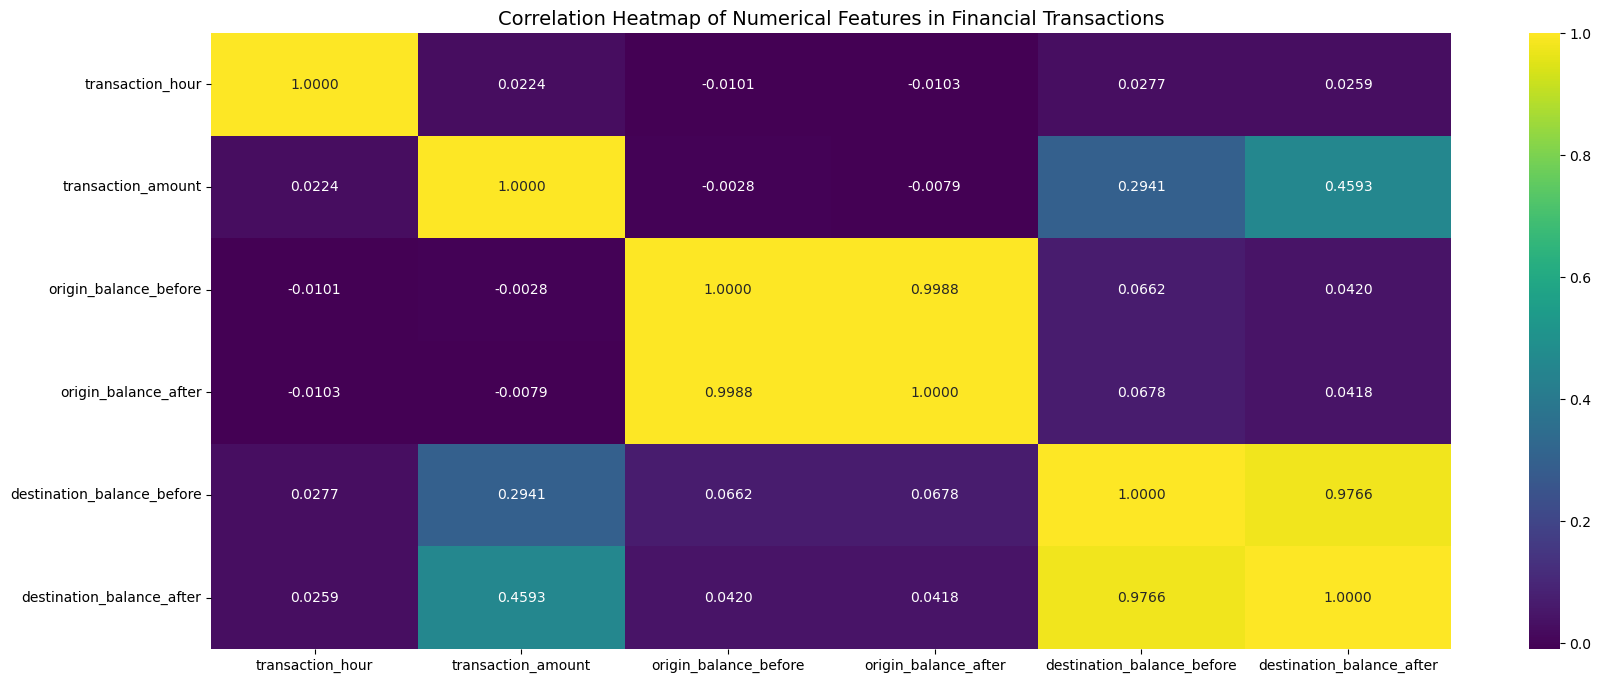

In [30]:
corr_df = data[numerical_columns].corr()

plt.figure(figsize=(20, 8))
sns.heatmap( corr_df, annot=True,fmt=".4f", cmap="viridis"
)

plt.title("Correlation Heatmap of Numerical Features in Financial Transactions", fontsize=14)
plt.show()


In [31]:
data_1 = data[data['flagged_as_fraud'] != 1].reset_index(drop = True)
data_1

,transaction_hour,transaction_type,transaction_amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud,flagged_as_fraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362599,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362600,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362601,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362602,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [45]:
data_1[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_hour,6362604.00,243.40,142.33,1.00,156.00,239.00,335.00,743.00
transaction_amount,6362604.00,179850.13,603788.43,0.00,13389.55,74871.27,208720.47,92445516.64
origin_balance_before,6362604.00,833865.54,2888205.23,0.00,0.00,14208.00,107314.00,59585040.37
origin_balance_after,6362604.00,855096.16,2924011.73,0.00,0.00,0.00,144255.37,49585040.37
destination_balance_before,6362604.00,1100704.43,3399183.94,0.00,0.00,132707.98,943041.69,356015889.35
destination_balance_after,6362604.00,1224999.48,3674133.05,0.00,0.00,214664.26,1111914.10,356179278.92


In [46]:
no_amount_df = data_1[data_1['transaction_amount'] == 0].reset_index(drop = True)
no_amount_df

,transaction_hour,transaction_type,transaction_amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud,flagged_as_fraud
0,212,CASH_OUT,0.00,C1510987794,0.00,0.00,C1696624817,0.00,0.00,1,0
1,250,CASH_OUT,0.00,C521393327,0.00,0.00,C480398193,0.00,0.00,1,0
2,279,CASH_OUT,0.00,C539112012,0.00,0.00,C1106468520,538547.63,538547.63,1,0
3,387,CASH_OUT,0.00,C1294472700,0.00,0.00,C1325541393,7970766.57,7970766.57,1,0
4,425,CASH_OUT,0.00,C832555372,0.00,0.00,C1462759334,76759.90,76759.90,1,0
5,425,CASH_OUT,0.00,C69493310,0.00,0.00,C719711728,2921531.34,2921531.34,1,0
6,554,CASH_OUT,0.00,C10965156,0.00,0.00,C1493336195,230289.66,230289.66,1,0
7,586,CASH_OUT,0.00,C1303719003,0.00,0.00,C900608348,1328472.86,1328472.86,1,0
8,617,CASH_OUT,0.00,C1971175979,0.00,0.00,C1352345416,0.00,0.00,1,0
9,646,CASH_OUT,0.00,C2060908932,0.00,0.00,C1587892888,0.00,0.00,1,0


In [47]:
no_amount_df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_hour,16.00,537.56,181.90,212.00,415.50,601.50,678.75,741.00
transaction_amount,16.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
origin_balance_before,16.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
origin_balance_after,16.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
destination_balance_before,16.00,904888.51,2036047.66,0.00,0.00,92268.46,656063.10,7970766.57
destination_balance_after,16.00,904888.51,2036047.66,0.00,0.00,92268.46,656063.10,7970766.57


In [48]:
no_amount_df['origin_account'].value_counts()

origin_account
C1510987794    1
C521393327     1
C539112012     1
C1294472700    1
C832555372     1
C69493310      1
C10965156      1
C1303719003    1
C1971175979    1
C2060908932    1
C1997645312    1
C1960007029    1
C1461113533    1
C729003789     1
C2088151490    1
C312737633     1
Name: count, dtype: int64

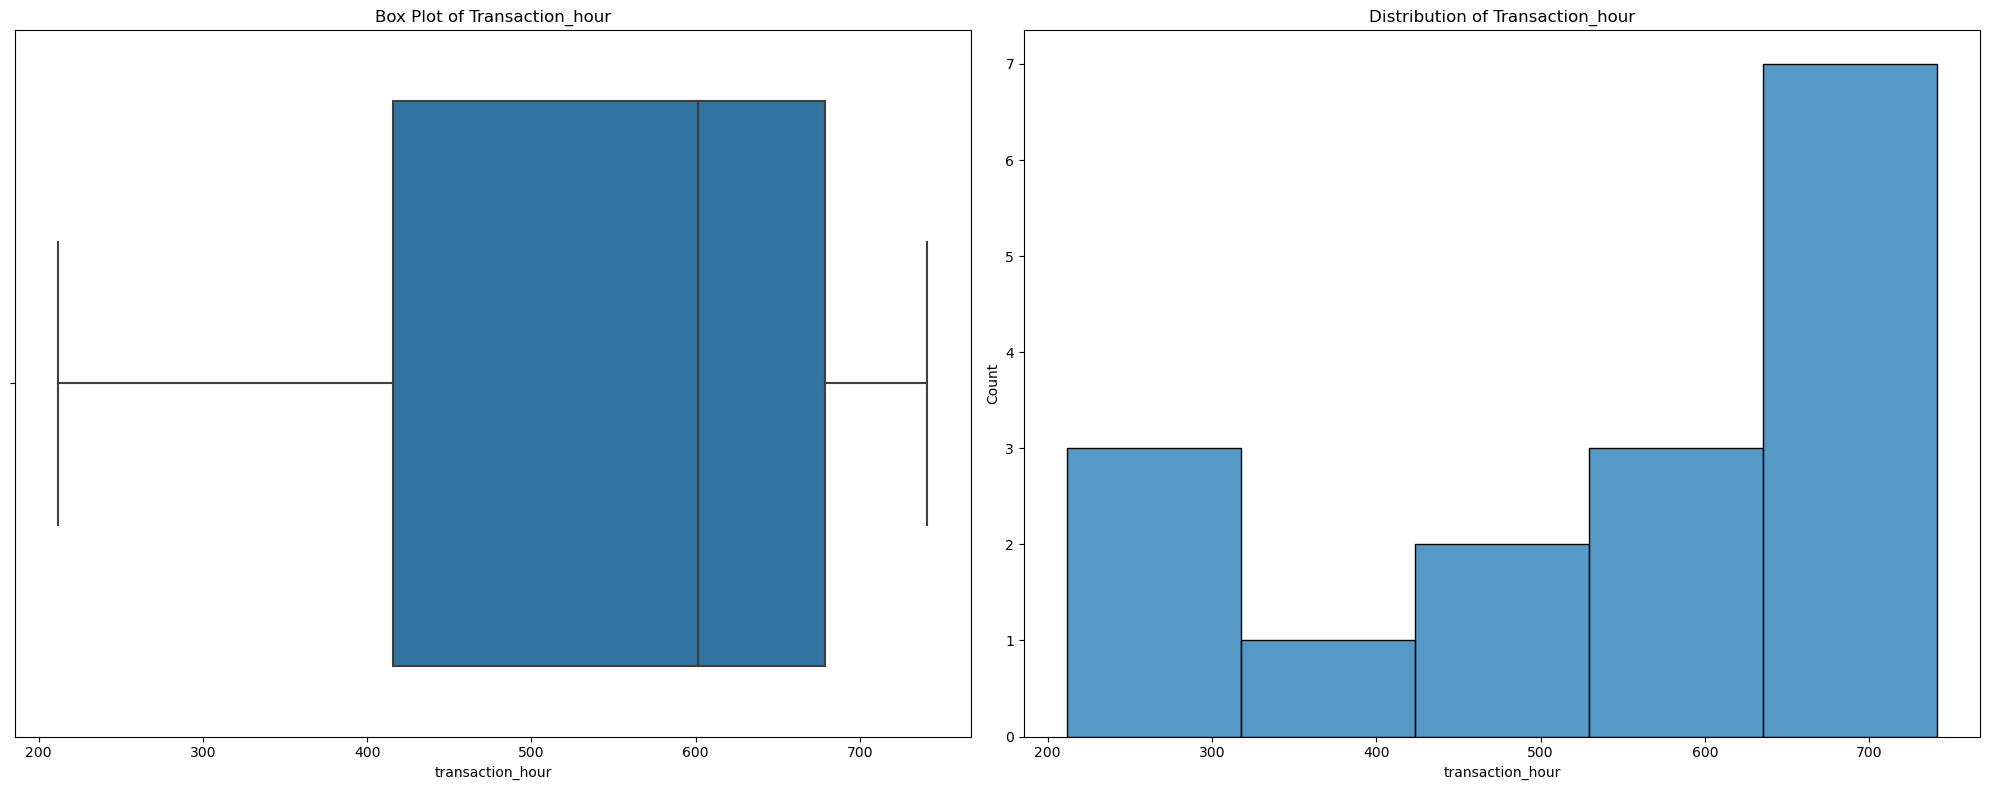

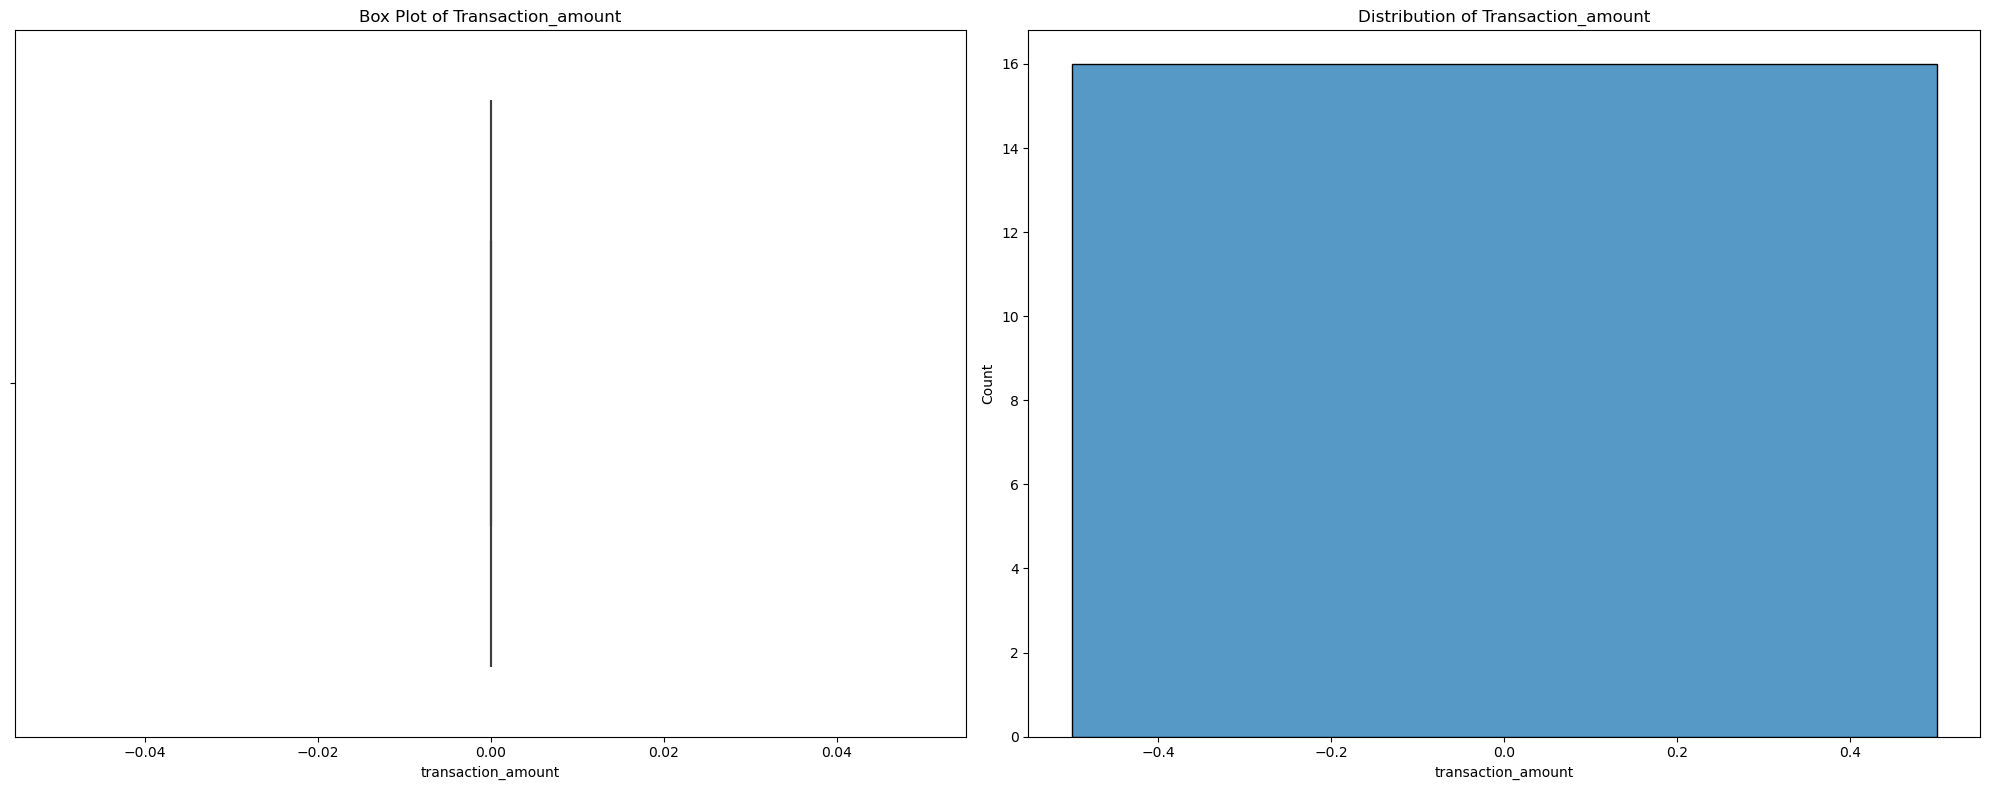

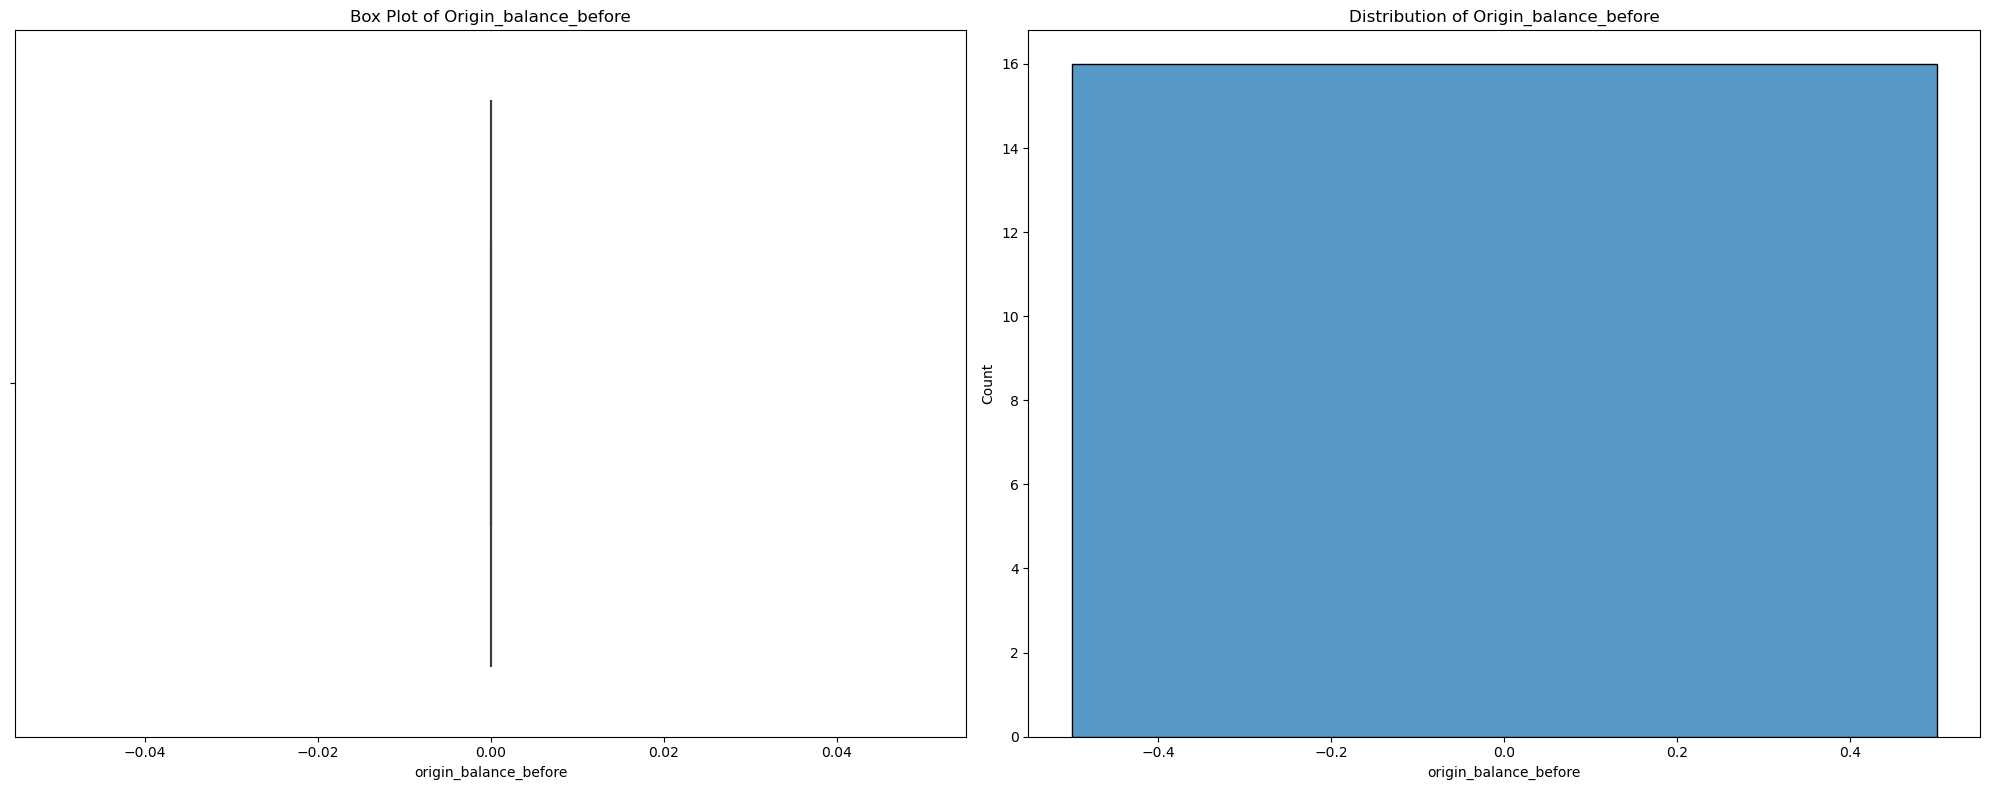

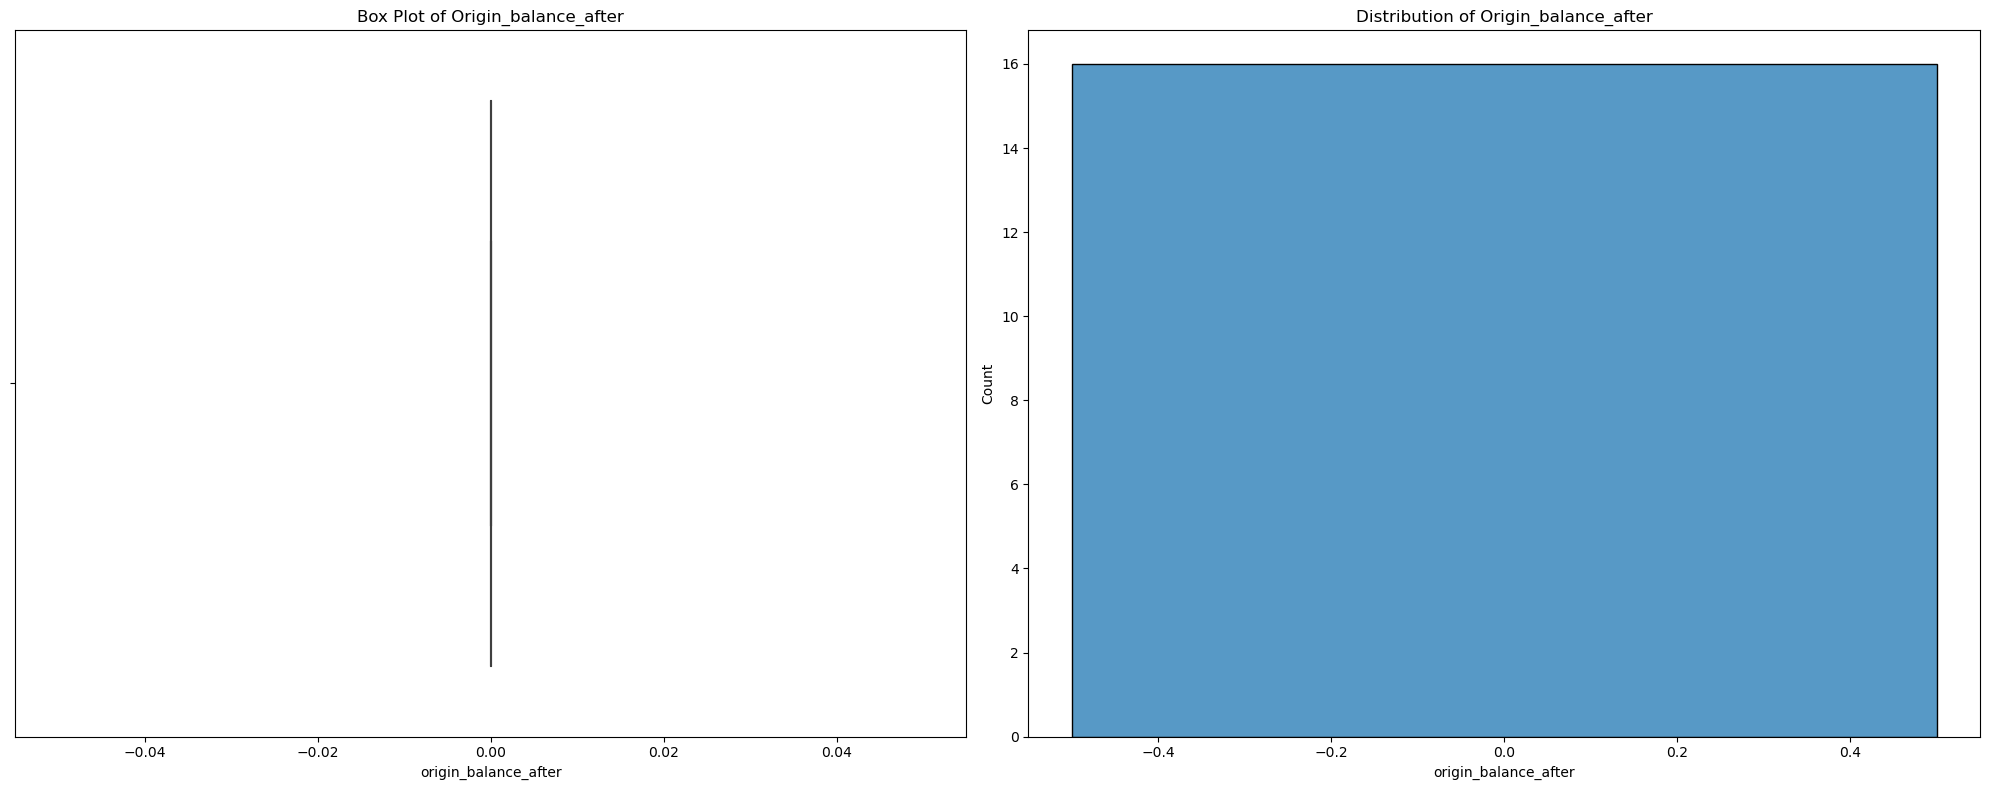

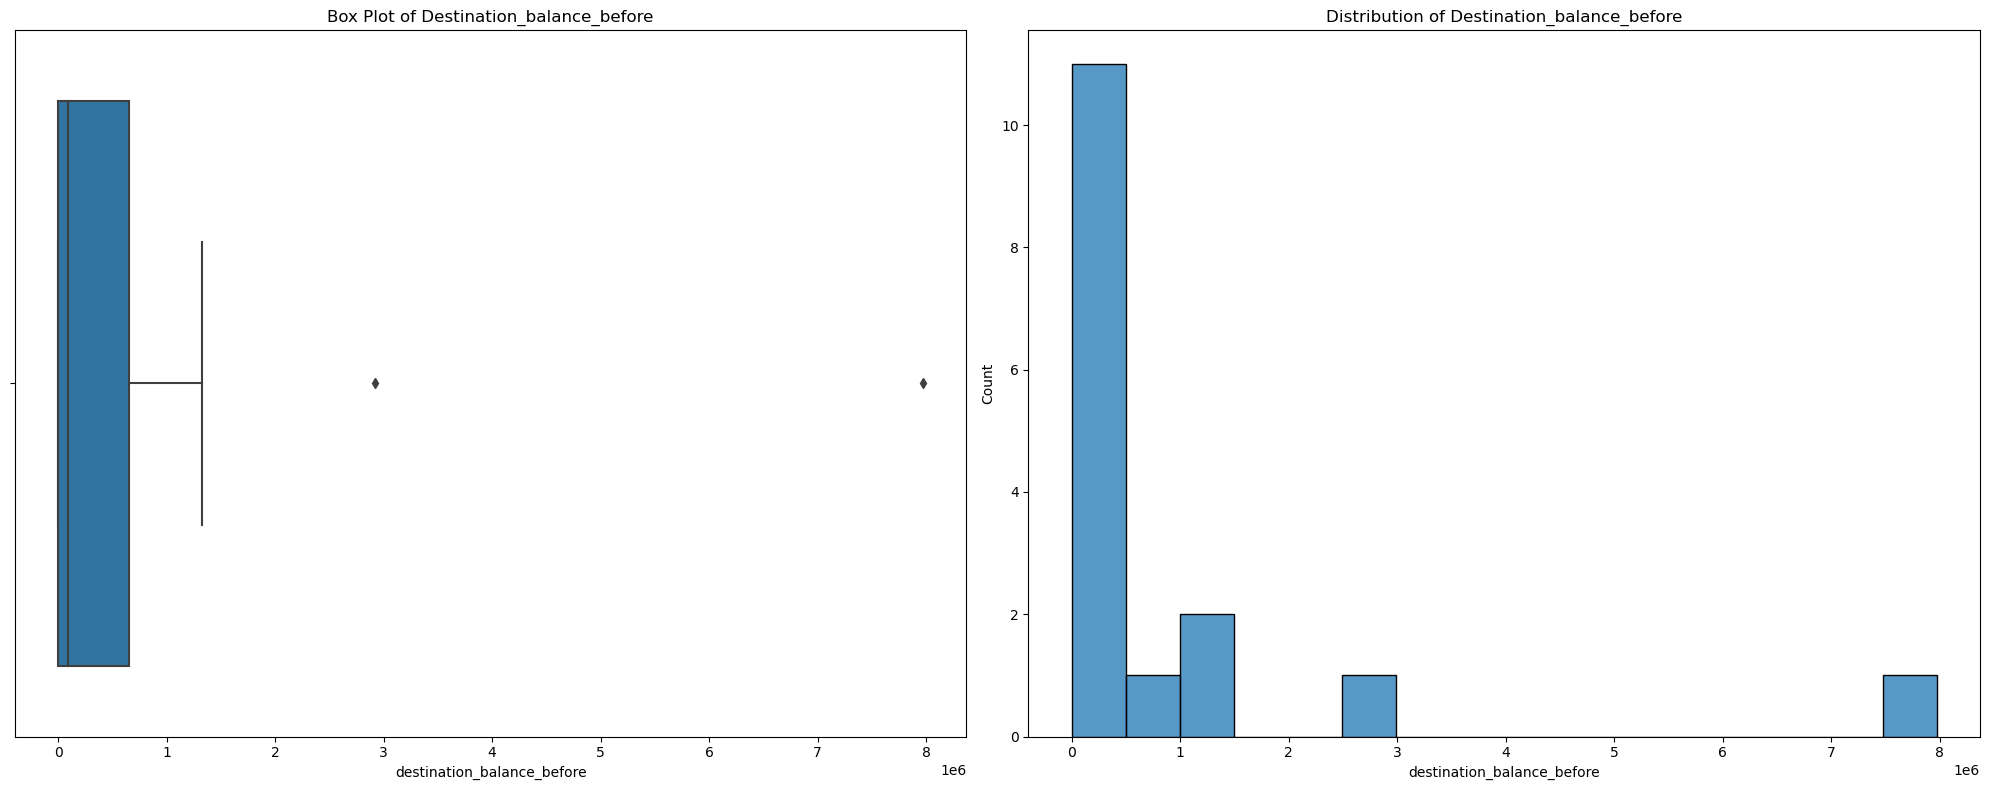

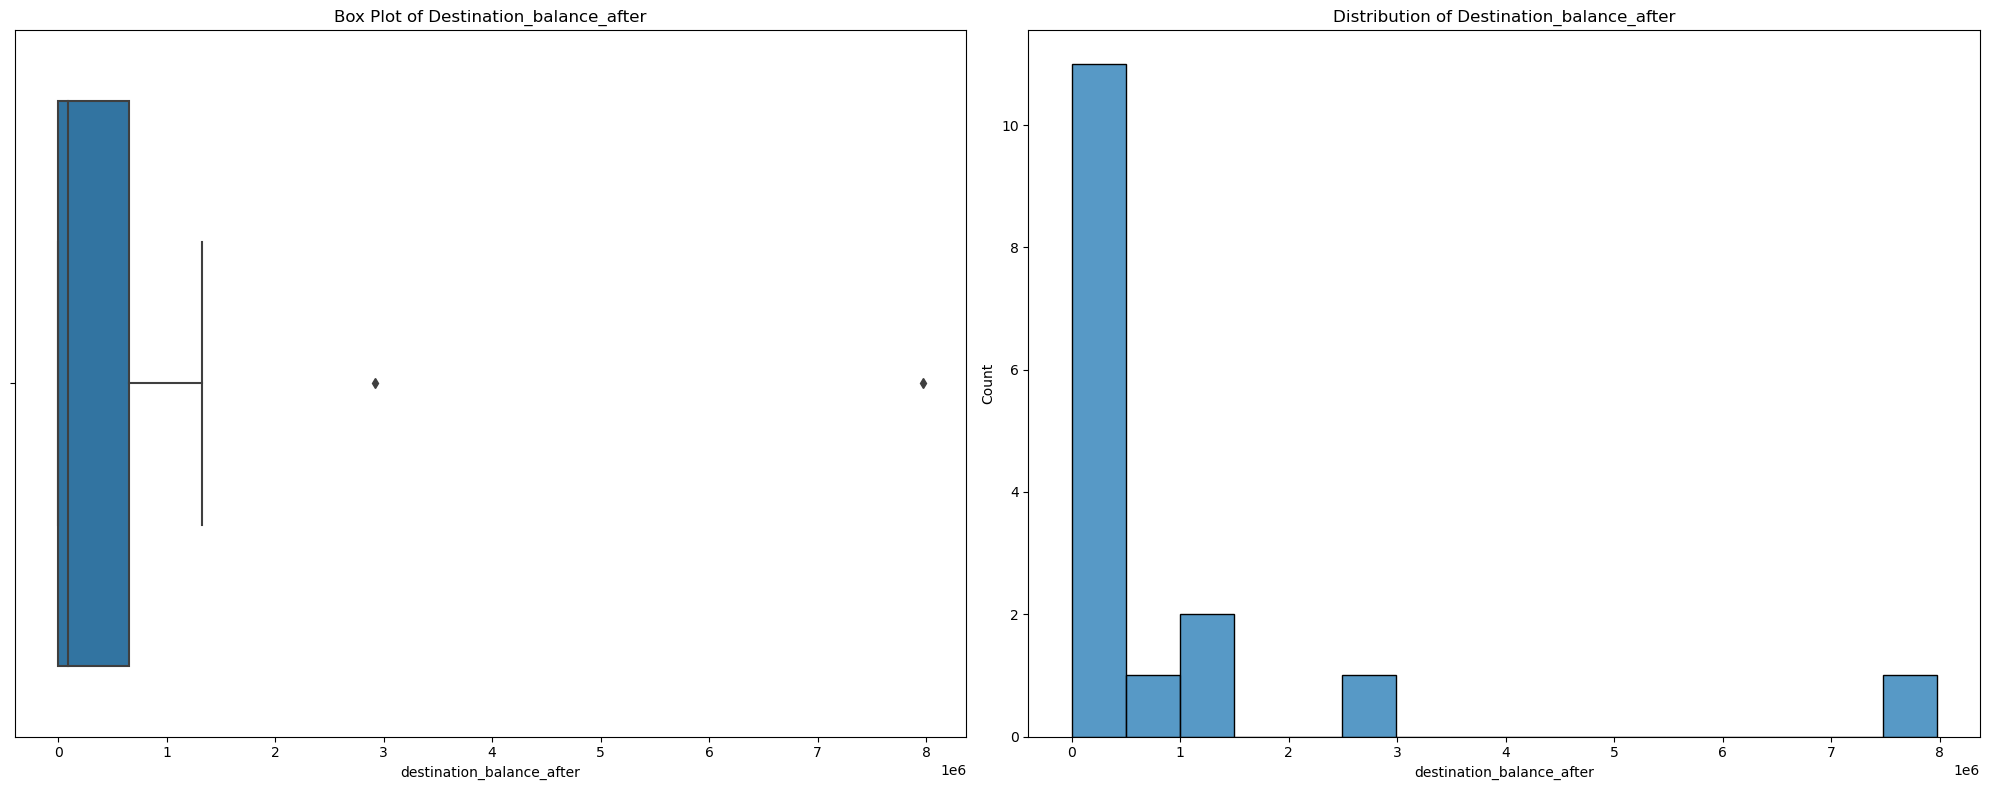

In [30]:
numerical_plot(no_amount_df)

In [31]:
##Testing the system principal

Zero-Amount CASH_OUT Fraud Explanation

In this case, no amount was transferred because the origin account had a zero balance at the time of the transaction. All the transactions occurred through the CASH_OUT method, which typically represents withdrawals made via ATM or POS terminals.

The destination account balance remained unchanged throughout all transactions, confirming that the withdrawal attempts were not successful and that no funds were received.

The rule-based detection system failed to flag these transactions as fraudulent because there was no monetary movement and the origin account balance was already zero. Since the system relies primarily on amount-based thresholds and balance changes, these transactions did not meet the conditions required for automatic flagging.

However, the post-transaction analysis system classified these transactions as fraud due to their abnormal behavioral patterns, such as repeated CASH_OUT attempts from empty accounts.

This clearly demonstrates that the existing detection system is rule-based rather than behavior-based, and highlights the need for behavioral modeling to identify subtle and non-traditional fraud patterns.

### Removing Zero-Amount Transactions

In [49]:
data_2 = data_1[data_1['transaction_amount'] != 0 ]
data_2

,transaction_hour,transaction_type,transaction_amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud,flagged_as_fraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362599,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362600,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362601,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362602,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


Some transactions in the dataset have a transaction amount of zero. These records do not represent actual money movement and may introduce noise into the analysis. Since the goal of this project is to study fraud behavior related to financial transfers, transactions with zero amount are excluded at this stage.

By applying this condition, a new dataset (data_2) is created that contains only transactions where a monetary value was involved. This helps improve the quality of exploratory analysis and ensures that subsequent modeling focuses on meaningful financial activity.


Zero-amount transactions do not contribute useful information for amount-based fraud patterns

Removing them simplifies analysis and interpretation

It reduces unnecessary noise in the dataset

### Fraud Attempts Involving Empty Destination Accounts

In [50]:
mask_2 = data_2["destination_balance_before"] == 0
mask_1 = data_2['destination_balance_after'] == 0
mask_3 = data_2['fraud'] ==1

df_1 = data_2[mask_1 & mask_2 & mask_3].reset_index(drop = True)
df_1

,transaction_hour,transaction_type,transaction_amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud,flagged_as_fraud
0,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
1,1,TRANSFER,2806.00,C1420196421,2806.00,0.00,C972765878,0.00,0.00,1,0
2,1,TRANSFER,20128.00,C137533655,20128.00,0.00,C1848415041,0.00,0.00,1,0
3,1,TRANSFER,1277212.77,C1334405552,1277212.77,0.00,C431687661,0.00,0.00,1,0
4,1,TRANSFER,35063.63,C1364127192,35063.63,0.00,C1136419747,0.00,0.00,1,0
...,...,...,...,...,...,...,...,...,...,...,...
4049,742,TRANSFER,63416.99,C778071008,63416.99,0.00,C1812552860,0.00,0.00,1,0
4050,743,TRANSFER,1258818.82,C1531301470,1258818.82,0.00,C1470998563,0.00,0.00,1,0
4051,743,TRANSFER,339682.13,C2013999242,339682.13,0.00,C1850423904,0.00,0.00,1,0
4052,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0


In [51]:
df_1.head(30)

,transaction_hour,transaction_type,transaction_amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud,flagged_as_fraud
0,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
1,1,TRANSFER,2806.00,C1420196421,2806.00,0.00,C972765878,0.00,0.00,1,0
2,1,TRANSFER,20128.00,C137533655,20128.00,0.00,C1848415041,0.00,0.00,1,0
3,1,TRANSFER,1277212.77,C1334405552,1277212.77,0.00,C431687661,0.00,0.00,1,0
4,1,TRANSFER,35063.63,C1364127192,35063.63,0.00,C1136419747,0.00,0.00,1,0
5,1,TRANSFER,25071.46,C669700766,25071.46,0.00,C1384210339,0.00,0.00,1,0
6,1,TRANSFER,235238.66,C1872047468,235238.66,0.00,C116289363,0.00,0.00,1,0
7,2,TRANSFER,1096187.24,C1093223281,1096187.24,0.00,C2063275841,0.00,0.00,1,0
8,2,TRANSFER,963532.14,C1440057381,963532.14,0.00,C268086000,0.00,0.00,1,0
9,2,TRANSFER,14949.84,C140702728,14949.84,0.00,C634210724,0.00,0.00,1,0


In [52]:
df_1[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_hour,4054.00,370.54,215.11,1.00,185.00,370.00,559.00,743.00
transaction_amount,4054.00,1472504.39,2407102.67,63.80,127649.70,442591.16,1530187.51,10000000.00
origin_balance_before,4054.00,1831234.80,4389480.98,63.80,127649.70,442591.16,1530187.51,59585040.37
origin_balance_after,4054.00,358730.41,2711779.19,0.00,0.00,0.00,0.00,49585040.37
destination_balance_before,4054.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
destination_balance_after,4054.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


Key Observations from Numerical Summary

1. Transaction Volume and Timing
A total of 4,054 fraud transactions fall into this category.
The transactions are spread across different hours, indicating that these attempts are not limited to a specific time window and may occur throughout the day.

2. Large Attempted Amounts
The average transaction amount is approximately ₦1.47 million, with some attempts reaching as high as ₦10 million.
Despite these large amounts, no money was successfully transferred to the destination accounts.

3. Source Account Balance Drain Attempts
The origin accounts typically had sufficient balance before the transaction.
After the attempt, the median origin balance drops to zero, indicating that these fraud attempts were designed to drain the source account completely.

4. No Destination Balance Change
Both the destination balance before and after the transaction remain exactly zero across all cases.
This confirms that these transactions did not result in any successful fund movement.

In [53]:
df_1['transaction_type'].value_counts()

transaction_type
TRANSFER    4052
CASH_OUT       2
Name: count, dtype: int64

In [54]:
#This shows that almost all failed fraud attempts in this category occur through TRANSFER transactions, 
#reinforcing the idea that transfers are the primary channel for fraud attempts.

In [55]:
df_1[df_1['transaction_type'] == 'CASH_OUT']

,transaction_hour,transaction_type,transaction_amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud,flagged_as_fraud
212,41,CASH_OUT,82806.20,C1327670146,82806.20,0.00,C1480756205,0.00,0.00,1,0
1016,185,CASH_OUT,131597.73,C1484249686,131597.73,0.00,C437393063,0.00,0.00,1,0


In [56]:
df_1['flagged_as_fraud'].value_counts()

flagged_as_fraud
0    4054
Name: count, dtype: int64

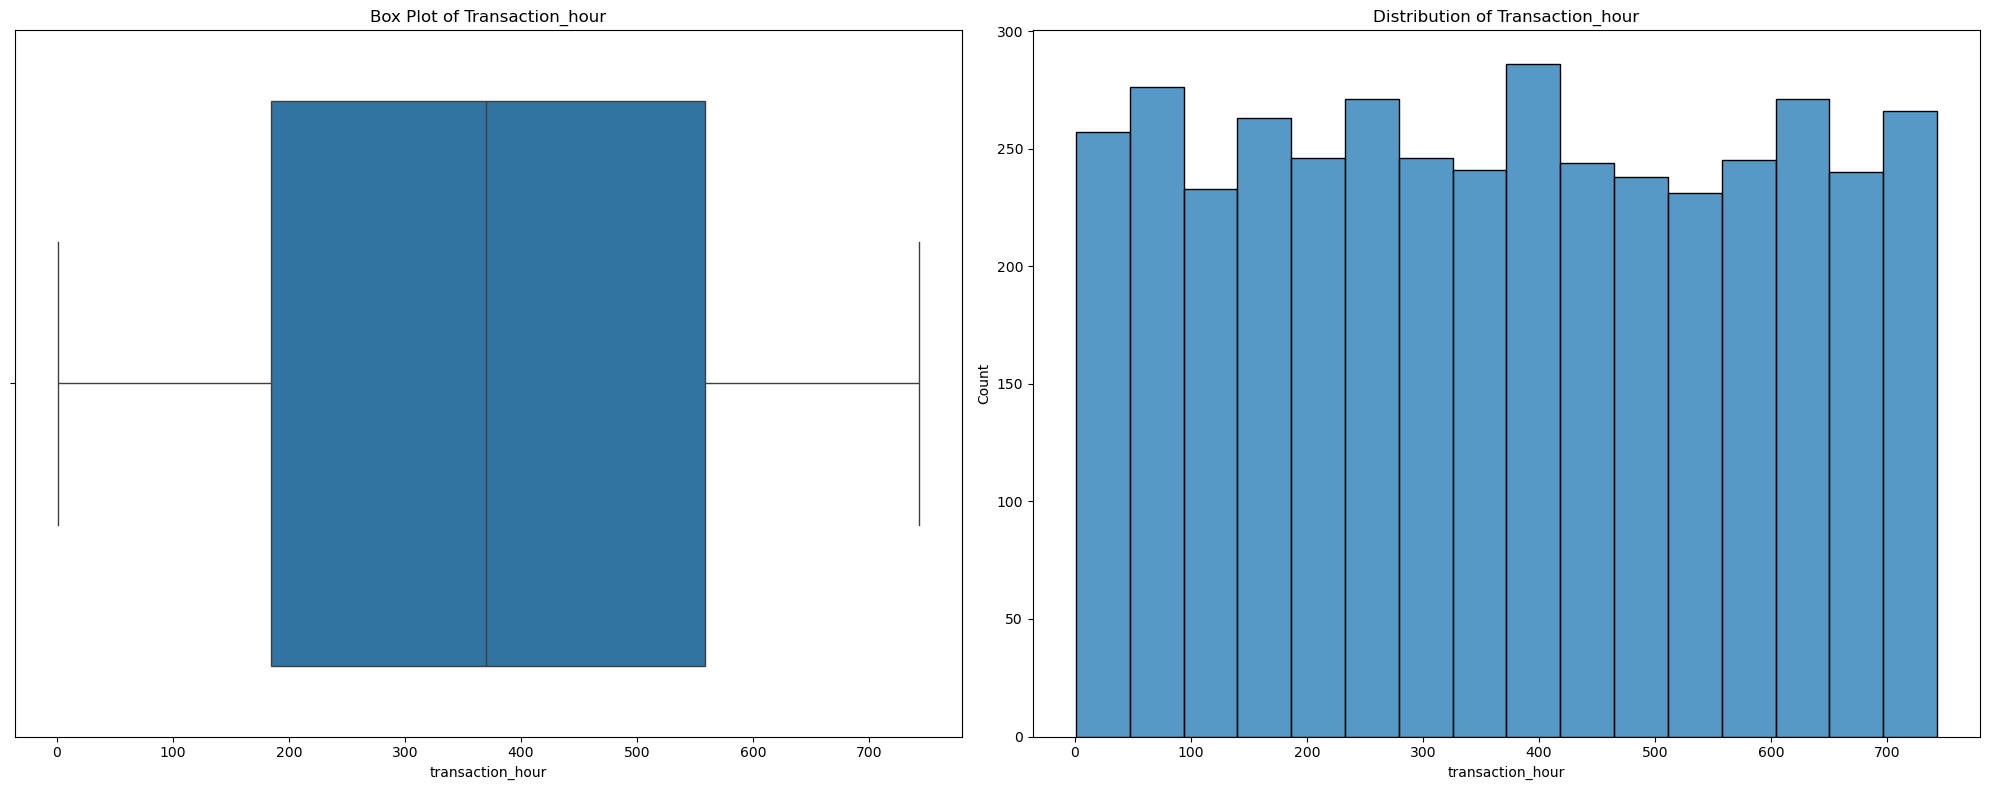

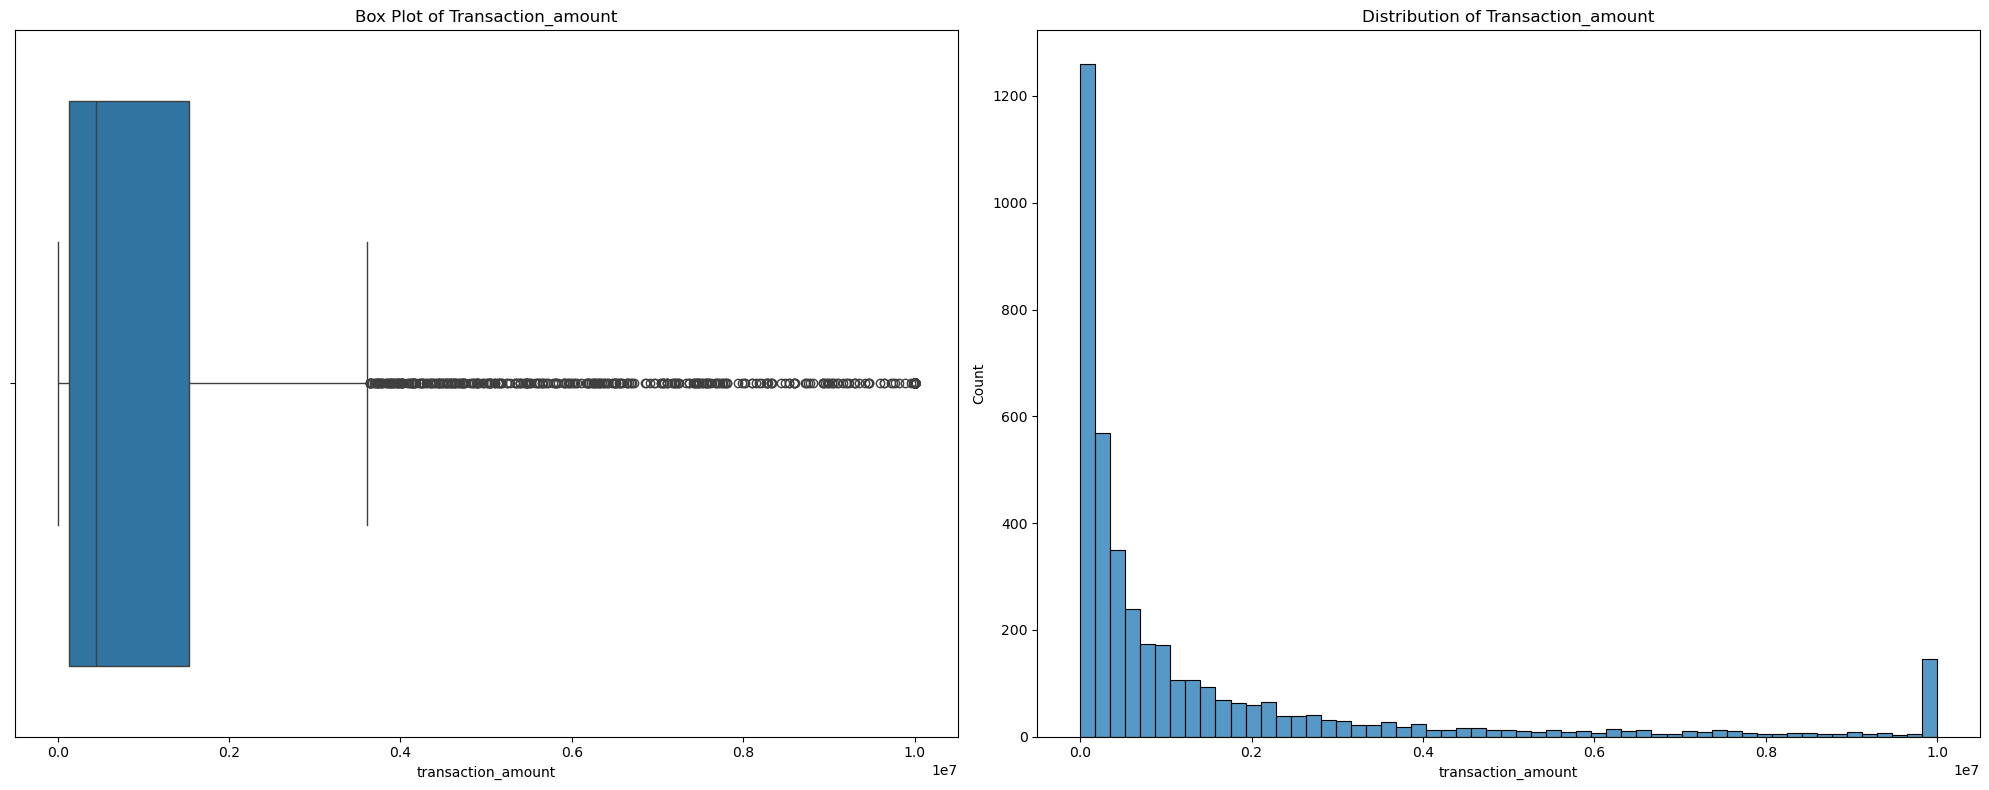

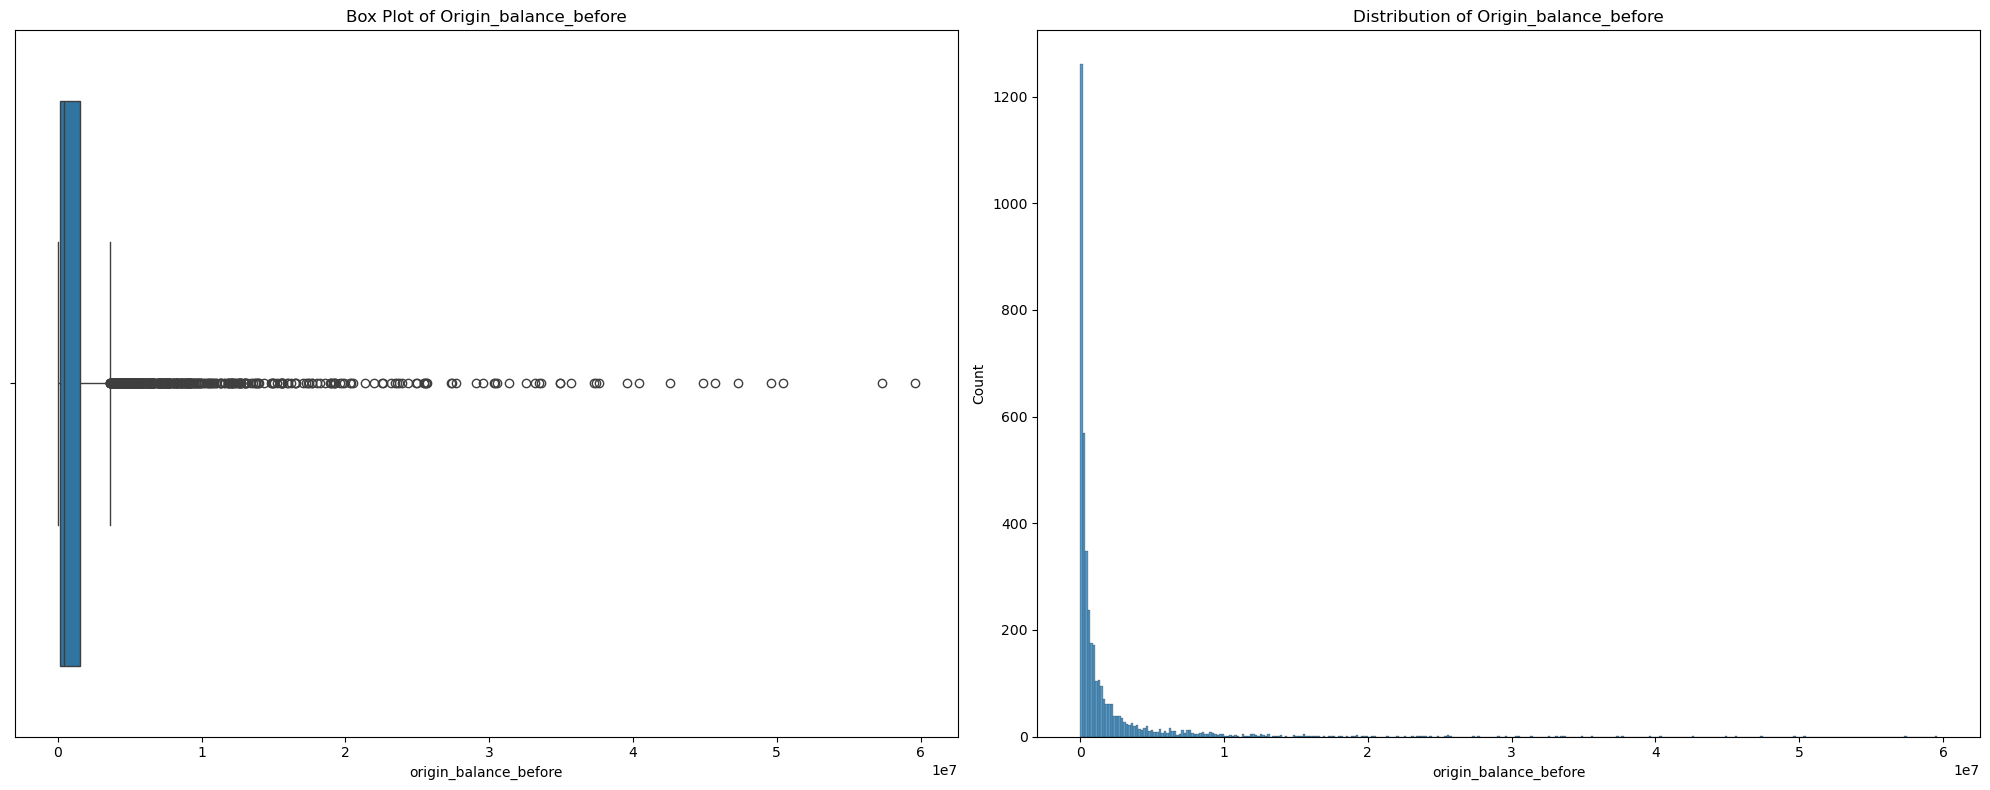

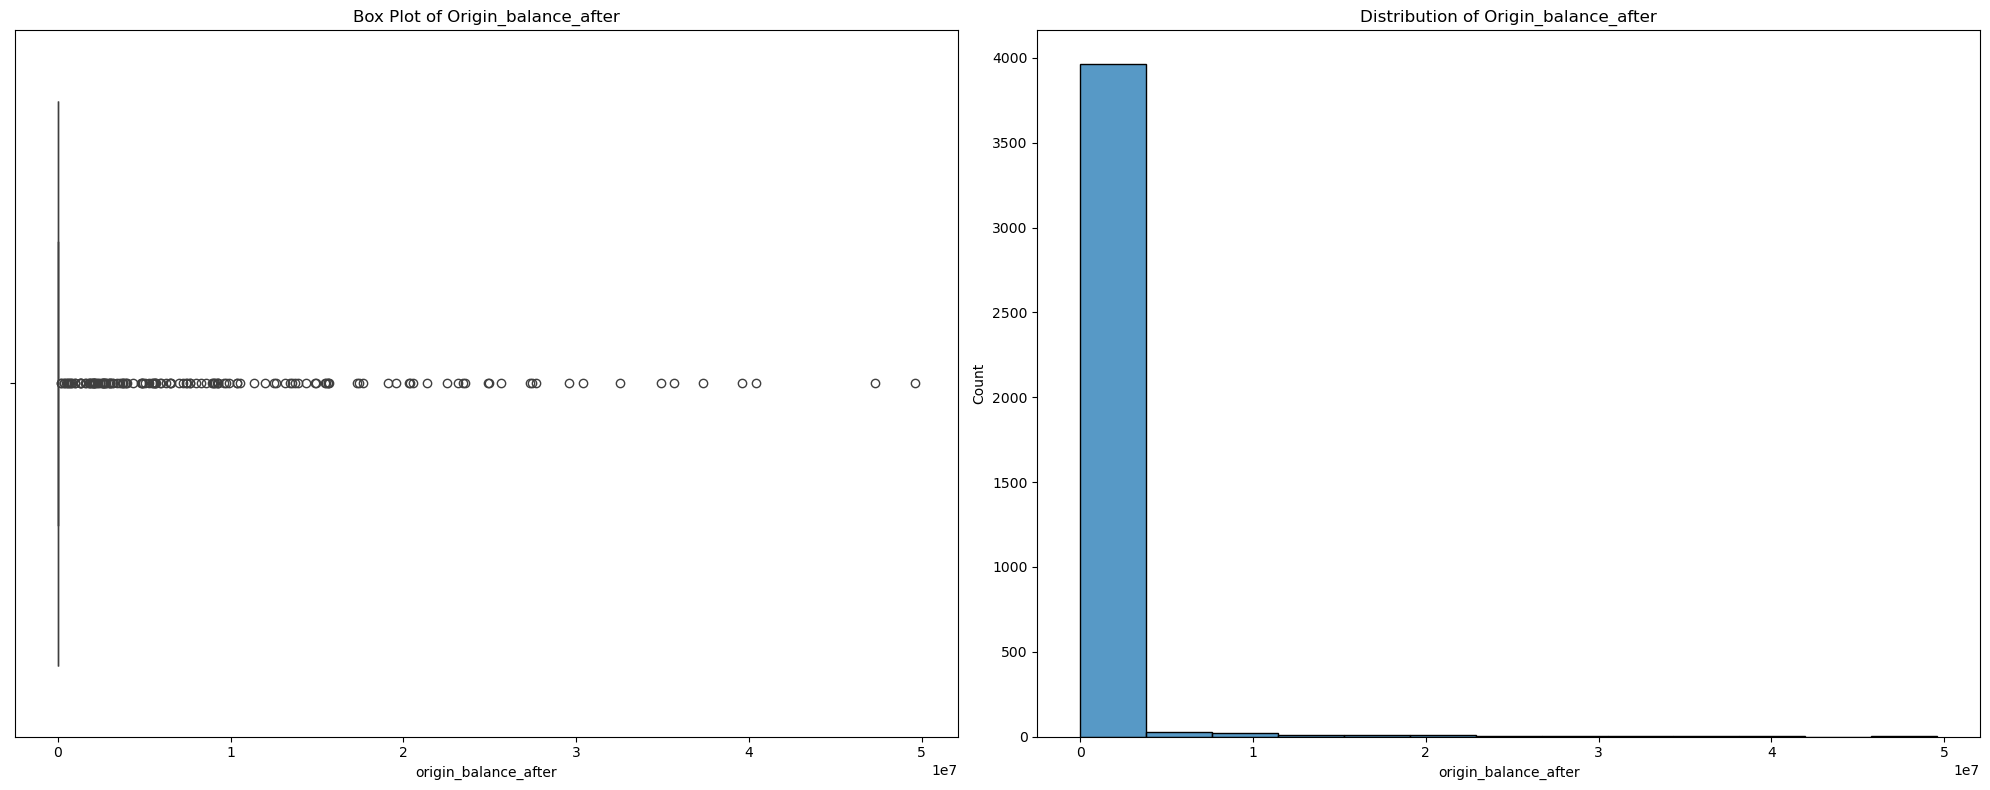

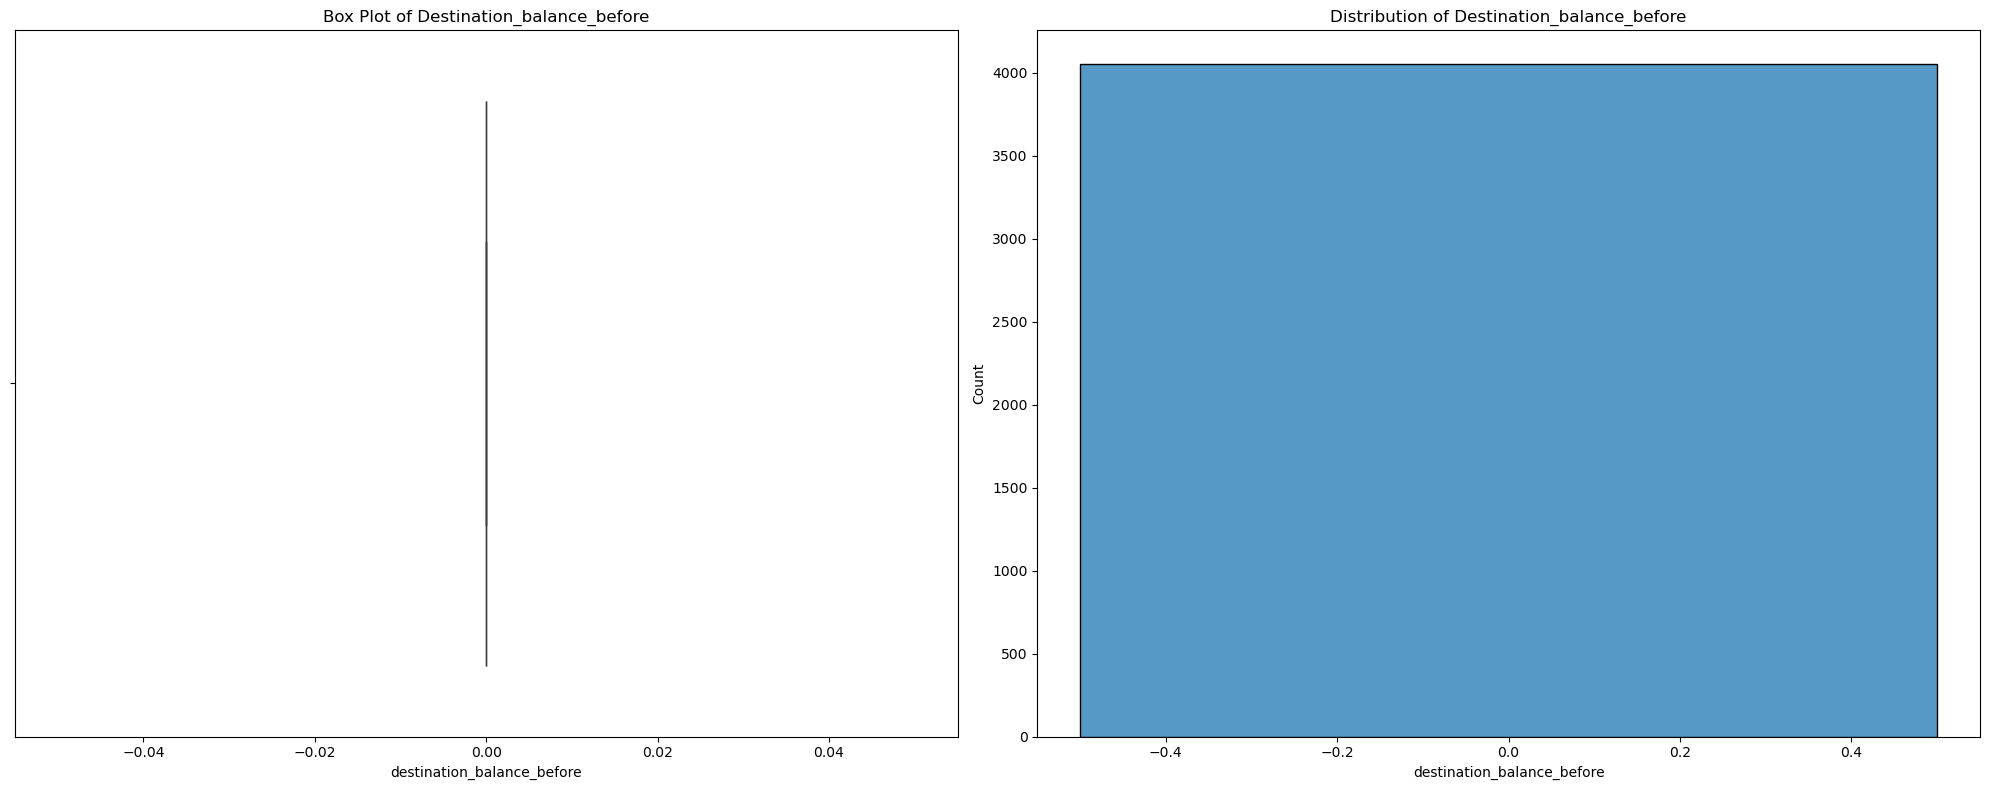

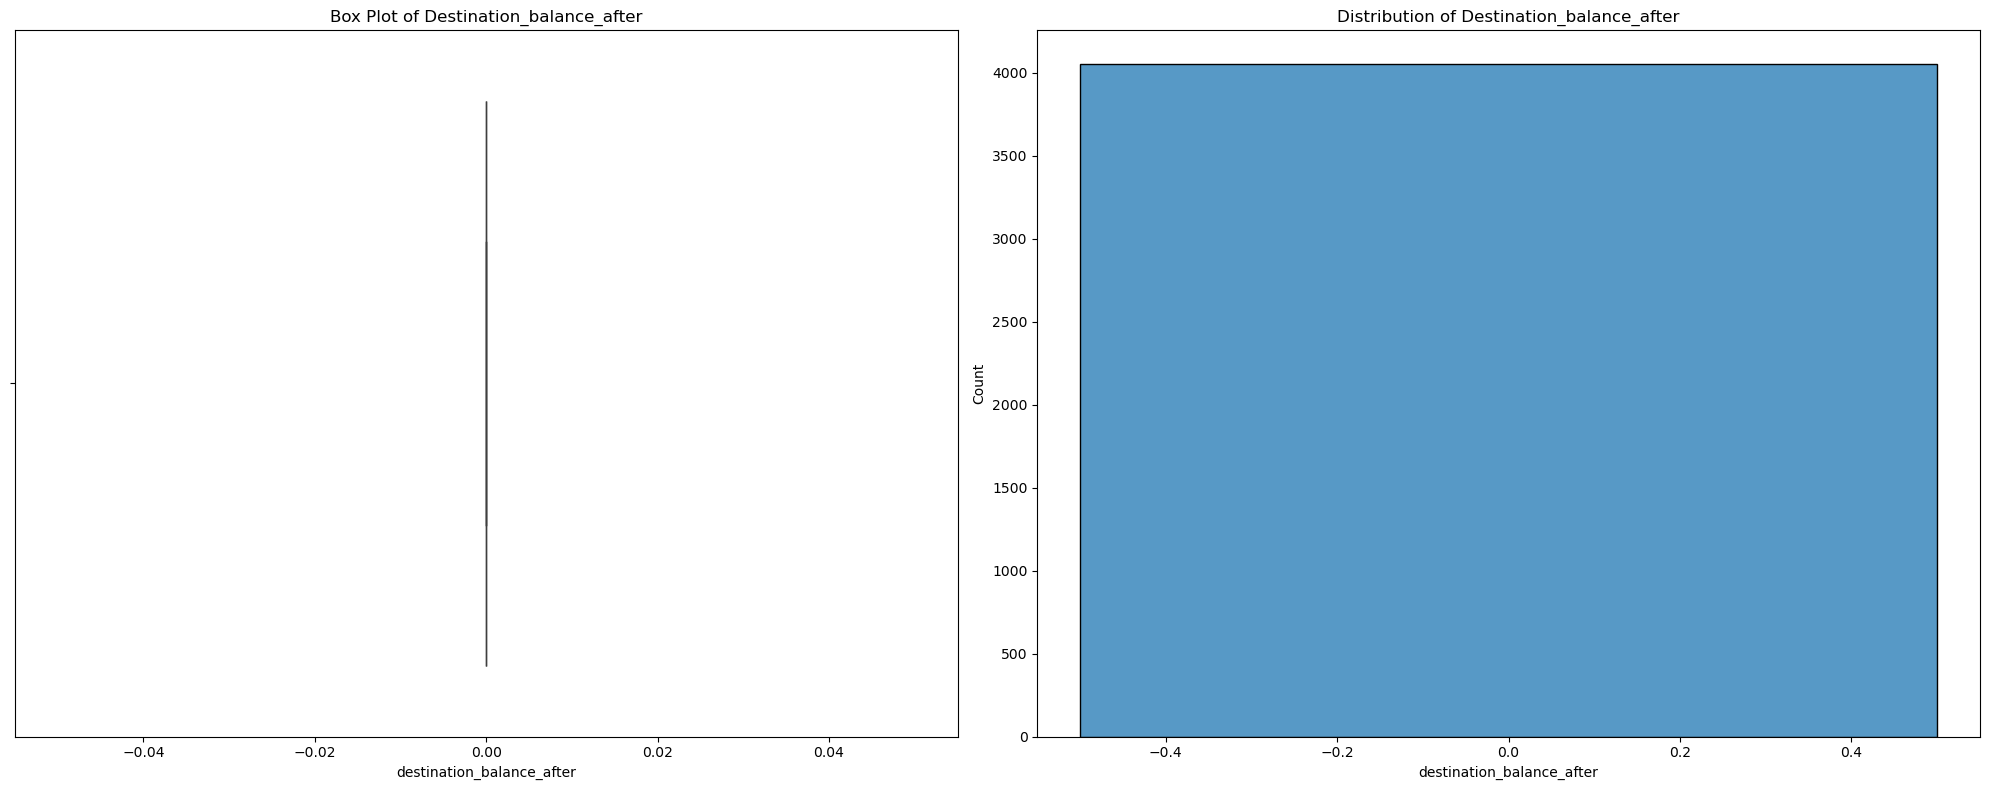

In [57]:
numerical_plot(df_1)

#Key Insights from the above subset

These transactions represent clear fraud intent without successful execution

High transaction amounts suggest aggressive attempts rather than random noise

Fraudsters aim to drain the origin account entirely in a single transaction

Traditional rule-based systems often ignore these cases because no money is lost

From a machine learning perspective, these patterns are valuable early warning signals

### Successful Fraud Transfers to Previously Empty Accounts

In [58]:
mask_2 = data_2["destination_balance_before"] == 0
mask_1 = data_2['destination_balance_after'] != 0
mask_3 = data_2['fraud'] ==1

df_1 = data_2[mask_1 & mask_2 & mask_3].reset_index(drop = True)
df_1

,transaction_hour,transaction_type,transaction_amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud,flagged_as_fraud
0,1,CASH_OUT,1277212.77,C467632528,1277212.77,0.00,C716083600,0.00,2444985.19,1,0
1,1,CASH_OUT,132842.64,C13692003,4499.08,0.00,C297927961,0.00,132842.64,1,0
2,1,CASH_OUT,235238.66,C1499825229,235238.66,0.00,C2100440237,0.00,235238.66,1,0
3,2,CASH_OUT,1096187.24,C77163673,1096187.24,0.00,C644345897,0.00,1096187.24,1,0
4,3,CASH_OUT,10539.37,C1984954272,10539.37,0.00,C124540047,0.00,10539.37,1,0
...,...,...,...,...,...,...,...,...,...,...,...
1270,741,CASH_OUT,144945.34,C1092829426,144945.34,0.00,C716019997,0.00,144945.34,1,0
1271,742,CASH_OUT,652993.91,C1614818636,652993.91,0.00,C362803701,0.00,652993.91,1,0
1272,742,CASH_OUT,1819543.69,C1039979813,1819543.69,0.00,C2078394828,0.00,1819543.69,1,0
1273,742,CASH_OUT,54652.46,C43545501,54652.46,0.00,C830041824,0.00,54652.46,1,0


This subset captures the classic and most damaging form of fraud:

A destination account starts with zero balance

A large transaction is executed

Funds successfully arrive in the destination account

This behavior is typical of mule accounts or newly created accounts used solely to receive stolen funds.

In [59]:
#In simple terms:
#the fraudster steals the money, but does not keep it in their own account.
#They move it through another account to hide their tracks.

In [60]:
payement_df = data[data['transaction_type'] == 'PAYMENT'].reset_index(drop = True)
payement_df

,transaction_hour,transaction_type,transaction_amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud,flagged_as_fraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
3,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.00,0.00,0,0
4,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
2151490,718,PAYMENT,8178.01,C1213413071,11742.00,3563.99,M1112540487,0.00,0.00,0,0
2151491,718,PAYMENT,17841.23,C1045048098,10182.00,0.00,M1878955882,0.00,0.00,0,0
2151492,718,PAYMENT,1022.91,C1203084509,12.00,0.00,M675916850,0.00,0.00,0,0
2151493,718,PAYMENT,4109.57,C673558958,5521.00,1411.43,M1126011651,0.00,0.00,0,0


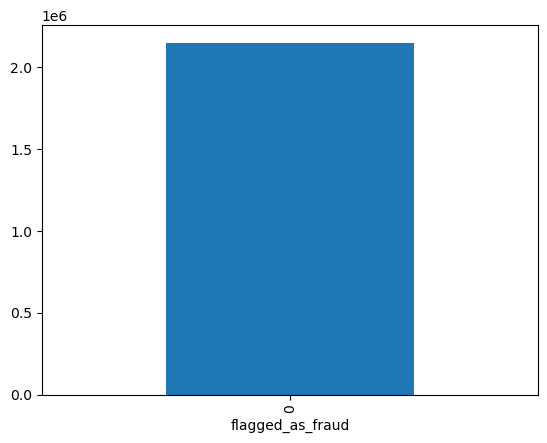

In [61]:
payement_df['flagged_as_fraud'].value_counts().plot(kind = "bar");

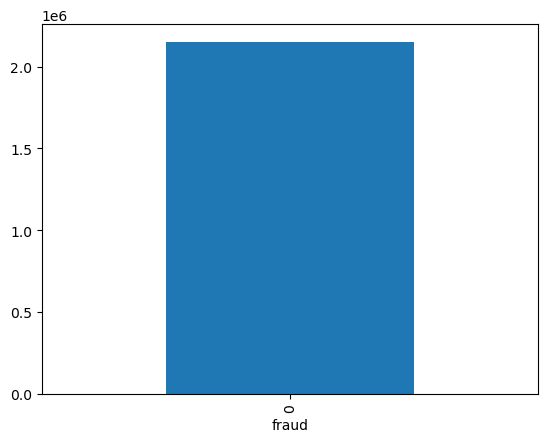

In [62]:
payement_df['fraud'].value_counts().plot(kind = "bar");

In [63]:
cash_in_df = data[data['transaction_type'] == 'CASH_IN'].reset_index(drop = True)
cash_in_df

,transaction_hour,transaction_type,transaction_amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud,flagged_as_fraud
0,1,CASH_IN,143236.26,C1862994526,0.00,143236.26,C1688019098,608932.17,97263.78,0,0
1,1,CASH_IN,228451.89,C1614133563,143236.26,371688.15,C2083562754,719678.38,1186556.81,0,0
2,1,CASH_IN,35902.49,C839771540,371688.15,407590.65,C2001112025,49003.30,0.00,0,0
3,1,CASH_IN,232953.64,C1037163664,407590.65,640544.28,C33524623,1172672.27,1517262.16,0,0
4,1,CASH_IN,65912.95,C180316302,640544.28,706457.23,C1330106945,104198.26,24044.18,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1399279,718,CASH_IN,188888.89,C1459052107,51838.00,240726.89,C1955750585,0.00,0.00,0,0
1399280,718,CASH_IN,27919.60,C562982749,2413.00,30332.60,C240654881,512791.59,484871.98,0,0
1399281,718,CASH_IN,78988.38,C886862695,204464.00,283452.38,C262804200,108724.19,29735.81,0,0
1399282,718,CASH_IN,18000.26,C50108853,63409.00,81409.26,C204102272,28088.61,10088.34,0,0


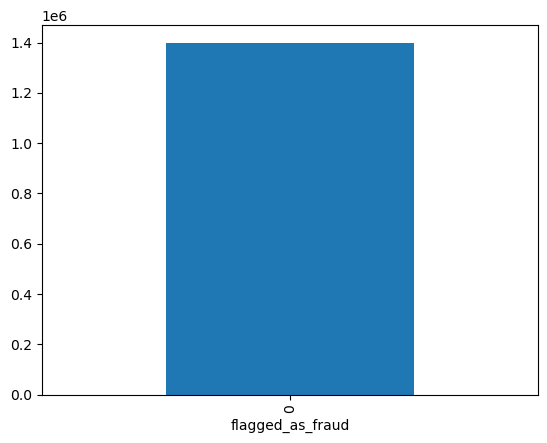

In [64]:
cash_in_df['flagged_as_fraud'].value_counts().plot(kind = "bar");

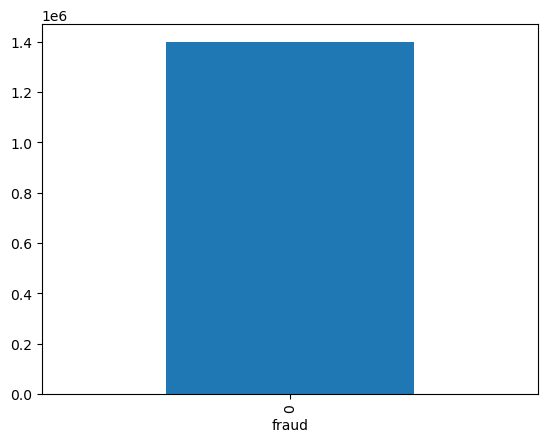

In [65]:
cash_in_df['fraud'].value_counts().plot(kind = "bar");

In [66]:
debit_df = data[data['transaction_type'] == 'DEBIT'].reset_index(drop = True)
debit_df

,transaction_hour,transaction_type,transaction_amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud,flagged_as_fraud
0,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.00,40348.79,0,0
1,1,DEBIT,9644.94,C1900366749,4465.00,0.00,C997608398,10845.00,157982.12,0,0
2,1,DEBIT,9302.79,C1566511282,11299.00,1996.21,C1973538135,29832.00,16896.70,0,0
3,1,DEBIT,1065.41,C1959239586,1817.00,751.59,C515132998,10330.00,0.00,0,0
4,1,DEBIT,5758.59,C1466917878,32604.00,26845.41,C1297685781,209699.00,16997.22,0,0
...,...,...,...,...,...,...,...,...,...,...,...
41427,718,DEBIT,2063.08,C397492133,328612.00,326548.92,C1557979171,1312720.98,1314784.06,0,0
41428,718,DEBIT,425.65,C1835928822,4046.00,3620.35,C701975669,3009282.73,3009708.38,0,0
41429,718,DEBIT,1636.03,C761454361,83120.00,81483.97,C355970563,8393318.02,8394954.05,0,0
41430,718,DEBIT,2148.99,C1909103796,49632.00,47483.01,C1931871221,66241.39,68390.38,0,0


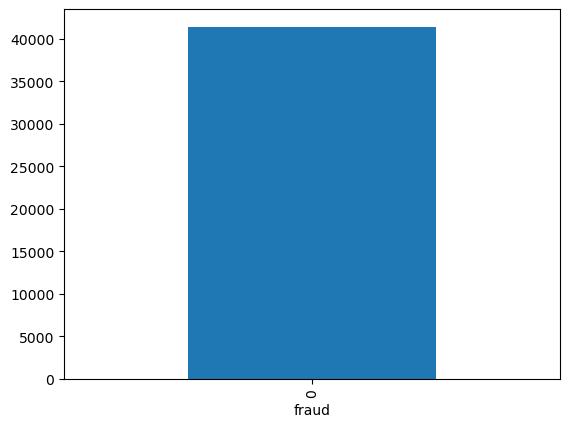

In [67]:
debit_df['fraud'].value_counts().plot(kind = "bar");

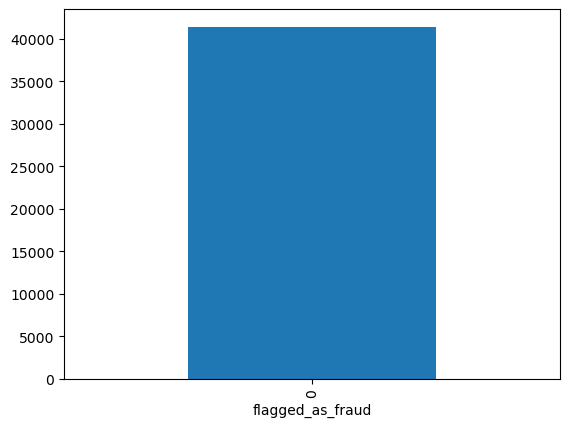

In [68]:
debit_df['flagged_as_fraud'].value_counts().plot(kind = "bar");

In [69]:
df_2 = data[(data['transaction_type'] == 'TRANSFER' ) | (data['transaction_type'] == 'CASH_OUT' )].reset_index(drop = True)
df_2

,transaction_hour,transaction_type,transaction_amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud,flagged_as_fraud
0,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
1,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
2,1,CASH_OUT,229133.94,C905080434,15325.00,0.00,C476402209,5083.00,51513.44,0,0
3,1,TRANSFER,215310.30,C1670993182,705.00,0.00,C1100439041,22425.00,0.00,0,0
4,1,TRANSFER,311685.89,C1984094095,10835.00,0.00,C932583850,6267.00,2719172.89,0,0
...,...,...,...,...,...,...,...,...,...,...,...
2770404,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
2770405,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
2770406,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
2770407,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [70]:
mask_4 = df_2['fraud'] == 1
fraud = df_2 [ mask_4]
fraud

,transaction_hour,transaction_type,transaction_amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud,flagged_as_fraud
0,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
1,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
123,1,TRANSFER,2806.00,C1420196421,2806.00,0.00,C972765878,0.00,0.00,1,0
124,1,CASH_OUT,2806.00,C2101527076,2806.00,0.00,C1007251739,26202.00,0.00,1,0
192,1,TRANSFER,20128.00,C137533655,20128.00,0.00,C1848415041,0.00,0.00,1,0
...,...,...,...,...,...,...,...,...,...,...,...
2770404,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
2770405,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
2770406,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
2770407,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


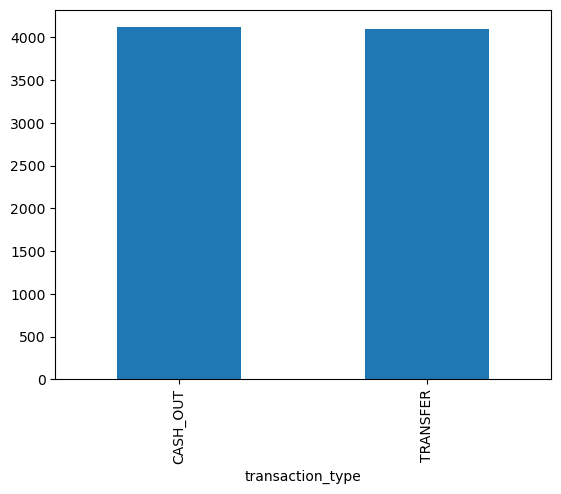

In [71]:
fraud['transaction_type'].value_counts().plot(kind = "bar");

In [72]:
fraud['flagged_as_fraud'].value_counts()

flagged_as_fraud
0    8197
1      16
Name: count, dtype: int64

In [73]:
data.columns

Index(['transaction_hour', 'transaction_type', 'transaction_amount',
       'origin_account', 'origin_balance_before', 'origin_balance_after',
       'destination_account', 'destination_balance_before',
       'destination_balance_after', 'fraud', 'flagged_as_fraud'],
      dtype='object')

## Dropping Unnecessary Features 

In [74]:
data = data.drop(columns= ['destination_account', 'origin_account', "flagged_as_fraud"] )

In [75]:
##Feature Engineering for non numerical colummns
data = pd.get_dummies(data, columns= ['transaction_type']).astype(int)
data

,transaction_hour,transaction_amount,origin_balance_before,origin_balance_after,destination_balance_before,destination_balance_after,fraud,transaction_type_CASH_IN,transaction_type_CASH_OUT,transaction_type_DEBIT,transaction_type_PAYMENT,transaction_type_TRANSFER
0,1,9839,170136,160296,0,0,0,0,0,0,1,0
1,1,1864,21249,19384,0,0,0,0,0,0,1,0
2,1,181,181,0,0,0,1,0,0,0,0,1
3,1,181,181,0,21182,0,1,0,1,0,0,0
4,1,11668,41554,29885,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,339682,339682,0,0,339682,1,0,1,0,0,0
6362616,743,6311409,6311409,0,0,0,1,0,0,0,0,1
6362617,743,6311409,6311409,0,68488,6379898,1,0,1,0,0,0
6362618,743,850002,850002,0,0,0,1,0,0,0,0,1


In [76]:
['transaction_hour', 'transaction_amount', 'origin_balance_before',
       'origin_balance_after', 'destination_balance_before',
       'destination_balance_after', 'fraud', 'transaction_type_CASH_IN',
       'transaction_type_CASH_OUT', 'transaction_type_DEBIT',
       'transaction_type_PAYMENT', 'transaction_type_TRANSFER'],


(['transaction_hour',
  'transaction_amount',
  'origin_balance_before',
  'origin_balance_after',
  'destination_balance_before',
  'destination_balance_after',
  'fraud',
  'transaction_type_CASH_IN',
  'transaction_type_CASH_OUT',
  'transaction_type_DEBIT',
  'transaction_type_PAYMENT',
  'transaction_type_TRANSFER'],)

In [77]:
##LOG transfromation to make the distribution less skewed 
num_columns = ['transaction_hour', 'transaction_amount', 'origin_balance_before',
       'origin_balance_after', 'destination_balance_before',
       'destination_balance_after']


for col in num_columns:
    data[col] = np.log1p(data[col])

In [78]:
####Scaling features to avoid bias that is to give all features the same strenght for better prediction

scaler = StandardScaler()
for col in num_columns:
    data[col] = scaler.fit_transform(data[[col]])

### Preparing Data for Model Training

In [79]:
##
X = data.drop(columns = ['fraud'])
y = data["fraud"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state= 42, stratify= y)

In [80]:


def evaluate_model (name, model):
    print(f"\n==================== {name} ====================\n")

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    print(f"Accuracy: {acc}")
    print(f"F1 Score: {f1}\n" )

    print("Classification Report:\n")
    print(classification_report(y_test, preds))


    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()




### Model Training and Evaluation


==================== Random Forest ====================



Accuracy: 0.9996924746933391
F1 Score: 0.8672246098167835

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.98      0.78      0.87      2464

    accuracy                           1.00   1908786
   macro avg       0.99      0.89      0.93   1908786
weighted avg       1.00      1.00      1.00   1908786



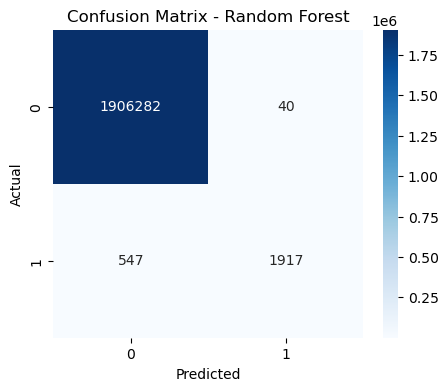

In [63]:
rf = RandomForestClassifier(random_state= 42)


evaluate_model("Random Forest", rf)


==================== Logistic Regression ====================

Accuracy: 0.999353515794856
F1 Score: 0.6868020304568528

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.92      0.55      0.69      2464

    accuracy                           1.00   1908786
   macro avg       0.96      0.77      0.84   1908786
weighted avg       1.00      1.00      1.00   1908786



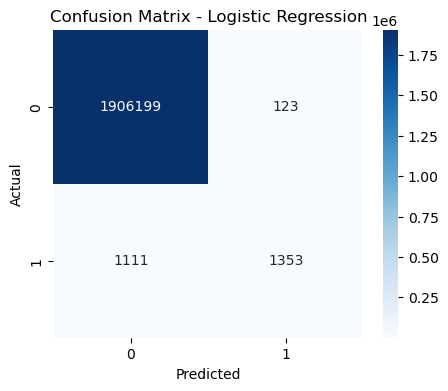

In [64]:
lg = LogisticRegression()

evaluate_model("Logistic Regression", lg)


==================== Lgbm Model ====================

Accuracy: 0.9896033395047952
F1 Score: 0.03444752590862648

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99   1906322
           1       0.02      0.14      0.03      2464

    accuracy                           0.99   1908786
   macro avg       0.51      0.57      0.51   1908786
weighted avg       1.00      0.99      0.99   1908786



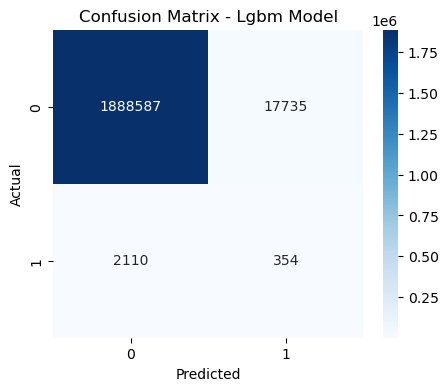

In [65]:
lgbm = LGBMClassifier(random_state= 42, verbosity = -1)

evaluate_model("Lgbm Model", lgbm)


==================== Catboost Model ====================

Accuracy: 0.9997810126436384
F1 Score: 0.9114781872088099

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.95      0.87      0.91      2464

    accuracy                           1.00   1908786
   macro avg       0.98      0.94      0.96   1908786
weighted avg       1.00      1.00      1.00   1908786



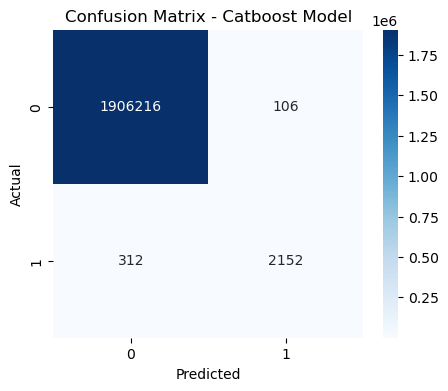

In [66]:
cat = CatBoostClassifier(random_state = 42 , verbose = 0)

evaluate_model("Catboost Model", cat)

Model Selection Summary

The fraud detection dataset is highly imbalanced, with fraudulent transactions representing only a very small fraction of the total data. In such cases, traditional models may achieve high accuracy while failing to correctly identify fraud cases.

CatBoost showed the best performance for this problem for several key reasons.

First, CatBoost handles class imbalance more effectively than many standard models. It focuses on learning hard-to-detect patterns rather than being biased toward the majority class. This improves the model’s ability to identify rare fraud cases.

Second, CatBoost captures complex relationships between transaction features such as balances, transaction type, and amount. Fraud behavior is rarely driven by a single feature; instead, it emerges from interactions between multiple variables. CatBoost is well-suited for learning these interactions.

Third, CatBoost is robust to noisy and irregular patterns, including failed fraud attempts and abnormal balance changes. These subtle behaviors are critical for early fraud detection and are often missed by simpler models.

Most importantly, CatBoost achieved better  F1-score, which is more meaningful metric than accuracy in fraud detection. High recall means fewer fraudulent transactions are missed, which directly reduces financial risk.

In [65]:
from sklearn.metrics import precision_score, recall_score

def evaluate_model(name, model):
    print(f"\n==================== {name} ====================\n")

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    precision = precision_score(y_test, preds )#average="weighted")
    recall = recall_score(y_test, preds )#, average="weighted")

    print(f"Precision: {precision}")
    print(f"Recall   : {recall}")


In [69]:
rf = RandomForestClassifier(random_state=42)
evaluate_model("Random Forest", rf)





==================== Random Forest ====================

Precision: 0.9795605518650996
Recall   : 0.7780032467532467


In [66]:
lg = LogisticRegression()
evaluate_model("Logistic Regression", lg)



==================== Logistic Regression ====================

Precision: 0.9166666666666666
Recall   : 0.5491071428571429


In [67]:

lgbm = LGBMClassifier(random_state=42, verbosity=-1)
evaluate_model("LGBM Model", lgbm)




==================== LGBM Model ====================

Precision: 0.01956990436176682
Recall   : 0.14366883116883117


In [68]:
cat = CatBoostClassifier(random_state=42, verbose=0)
evaluate_model("CatBoost Model", cat)


==================== CatBoost Model ====================

Precision: 0.9530558015943312
Recall   : 0.8733766233766234


In [ ]:
# Stratified K-Fold
skf = StratifiedKFold(
    n_splits= 4,
    shuffle=True,      
    random_state=42
)

f1_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    print(f"Fold {fold}")

    # Split data
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # CatBoost model
    model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="F1",
        verbose=False,
        random_state=42
    )

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_val)

    # F1 score
    f1 = f1_score(y_val, y_pred, average="weighted")
    f1_scores.append(f1)

    print(f"F1 Score: {f1:.4f}\n")

print("Cross-Validation Results")
print(f"Mean F1 Score: {np.mean(f1_scores):.4f}")
print(f"Std F1 Score:  {np.std(f1_scores):.4f}")



Fold 1
F1 Score: 0.9998

Fold 2
F1 Score: 0.9998

Fold 3
F1 Score: 0.9997

Fold 4
F1 Score: 0.9998

Cross-Validation Results
Mean F1 Score: 0.9998
Std F1 Score:  0.0000


In [68]:
cat_model = CatBoostClassifier(
    eval_metric="TotalF1",
    random_state=42,
    verbose=False
)

cat_model.fit(X_train, y_train)


In [69]:
import joblib
import os

joblib.dump(cat_model, "fraud_detection_model.pkl")


['fraud_detection_model.pkl']